## Setup, Loading Data and CDFs

In [1]:
DATA_NAME = 'syntheticMRI2D-axial' 
TRANSFORM = 'wavelet-horizontal'
CHANNEL = ''

In [2]:
path_list = DATA_NAME.split("-") + TRANSFORM.split("-")
if CHANNEL:
    path_list.append(CHANNEL)
print(f"Name the notebook:\n{'_'.join(path_list[::-1])}.ipynb")
FULL_DATA_NAME='-'.join(path_list)

Name the notebook:
horizontal_wavelet_axial_syntheticMRI2D.ipynb


In [3]:
import git
from pathlib import Path
import os

ROOT_DIR = Path(git.Repo('.', search_parent_directories=True).working_tree_dir)
CWD = os.path.join(ROOT_DIR, "results", "case-studies", *path_list)

assert CWD == os.getcwd()
Path(os.path.join(CWD, "CSVs")).mkdir(exist_ok=True)
Path(os.path.join(CWD, "plots")).mkdir(exist_ok=True)
Path(os.path.join(CWD, "cache")).mkdir(exist_ok=True)

GROUP = 'layer' if TRANSFORM.split("-")[0] == 'wavelet' else ('band' if TRANSFORM.split("-")[0] == 'fourier' else 'error')
RERUN = False
SKIP_OPTIMIZE_STEP = False
CWD

'/Users/brandonmarks/Desktop/hierarchical-bayesian-model-validation/results/case-studies/syntheticMRI2D/axial/wavelet/horizontal'

In [4]:
os.chdir(os.path.join(ROOT_DIR, "utilities"))
from testing import * # If MATLAB is not installed, open utilities and set to False
from plotting import *
os.chdir(CWD)
np.random.seed(0)

In [5]:
group_data_map = pd.read_pickle(os.path.join(ROOT_DIR, "transformed-data", f'{FULL_DATA_NAME}.pickle'))
group_total_samples = pd.read_pickle(os.path.join(ROOT_DIR, "transformed-data", f'{FULL_DATA_NAME}-size.pickle'))

In [6]:
if 'fourier' in TRANSFORM:
    GROUPS = np.arange(2, sorted(group_data_map)[-1] + 1)[::3]
elif 'wavelet' in TRANSFORM:
    GROUPS = np.arange(2, sorted(group_data_map)[-1] + 1)

cdfs_dir = os.path.join(ROOT_DIR, "results", "CDFs")
cdfs_list = sorted([os.path.join(cdfs_dir, i) for i in os.listdir(cdfs_dir)])
all_cdfs = combine_pickles(cdfs_list[0])
for cdf_dir in cdfs_list[:6]: # TODO For quick testing purposes. Currently excluding 20000 CDFs. Use cdfs_list[5:6] to access CDFs/_test
    all_cdfs = all_cdfs | combine_pickles(cdf_dir)
    
# group_data_map = {g : group_data_map[g][::100] for g in GROUPS} # TODO For quick testing purposes
group_total_samples

{2: 4,
 3: 20050,
 4: 180942,
 5: 922650,
 6: 4185552,
 7: 17688454,
 8: 72685058,
 9: 295085108}

Running 12760 CDFs


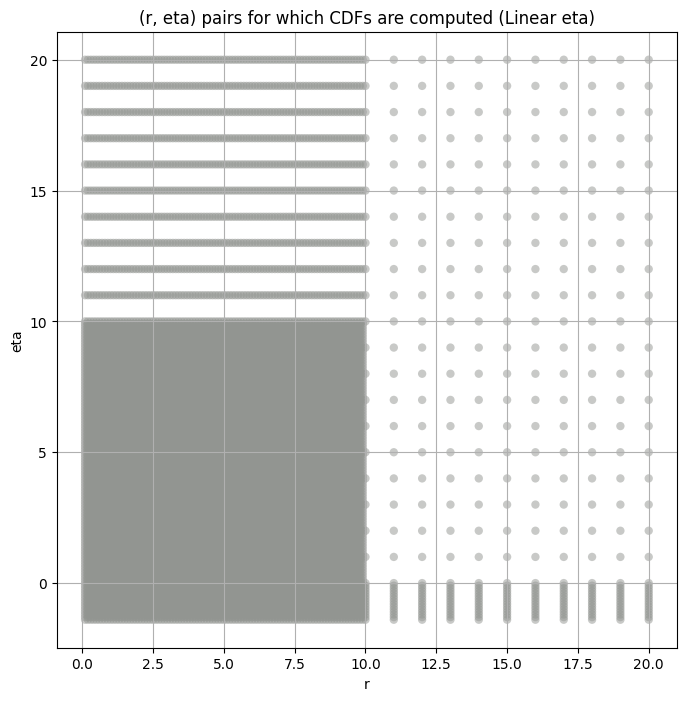

,"(r,eta),cdf",r,eta,cdf,variance,kurtosis
0,"((0.1, -1.4), <scipy.interpolate._fitpack2.Int...",0.1,-1.4,<scipy.interpolate._fitpack2.InterpolatedUniva...,3.628800e+06,554265.000000
1,"((0.1, -1.3), <scipy.interpolate._fitpack2.Int...",0.1,-1.3,<scipy.interpolate._fitpack2.InterpolatedUniva...,3.991680e+07,96192.272727
2,"((0.1, -1.2), <scipy.interpolate._fitpack2.Int...",0.1,-1.2,<scipy.interpolate._fitpack2.InterpolatedUniva...,2.395008e+08,29390.000000
3,"((0.1, -1.1), <scipy.interpolate._fitpack2.Int...",0.1,-1.1,<scipy.interpolate._fitpack2.InterpolatedUniva...,1.037837e+09,11997.692308
4,"((0.1, -1.0), <scipy.interpolate._fitpack2.Int...",0.1,-1.0,<scipy.interpolate._fitpack2.InterpolatedUniva...,3.632429e+09,5874.890110


In [7]:
warnings.filterwarnings('ignore', category=RuntimeWarning)

all_cdfs_df = create_kurt_var_ksstat_df(all_cdfs)
fine_cdfs_df = all_cdfs_df.copy()
all_cdfs_df = all_cdfs_df[(np.round(all_cdfs_df['r'], 1) == all_cdfs_df['r']) & (np.round(all_cdfs_df['eta'], 1) == all_cdfs_df['eta'])]
all_cdfs_df = all_cdfs_df.reset_index(drop=True)
all_cdfs = {x[0] : x[1] for x in all_cdfs_df["(r,eta),cdf"]}
                                             
var_values_dict = dict()
kurt_values_dict = dict()
master_df = pd.DataFrame(columns=[GROUP]).set_index(GROUP)
temp_cdf = all_cdfs_df
print(f"Running {all_cdfs_df.shape[0]} CDFs")
create_scatter_plot(all_cdfs_df);
all_cdfs_df.head()

## Bootstrapping the Variance and Kurtosis

In [8]:
n_bootstrap = int(1e5) # TODO For quick testing purposes
bootstrap_size = int(1e4) # TODO For quick testing purposes
ci = 0.99

In [9]:
bootstrap_path = Path(os.path.join(CWD, "CSVs", f'initial_grid_bootstrap{n_bootstrap}_{bootstrap_size}_ci{ci}.csv'))
master_df_var_kurt_path = Path(os.path.join(CWD, "CSVs", f'initial_grid_bootstrap{n_bootstrap}_{bootstrap_size}_ci{ci}.csv'))

if RERUN or not master_df_var_kurt_path.exists(): # TODO For quick testing purposes
    for group in GROUPS:
        print(f'{GROUP.capitalize()} {group}')
        obs_var, var_lower, var_upper, var_values_dict[group] = bootstrap_metric(group_data_map[group], 
                                                                                n_bootstrap=n_bootstrap, 
                                                                                bootstrap_size=min(group_data_map[group].size, bootstrap_size), 
                                                                                metric= np.var, 
                                                                                ci=ci)
        obs_kurt, kurt_lower, kurt_upper, kurt_values_dict[group] = bootstrap_metric(group_data_map[group], 
                                                                                    n_bootstrap=n_bootstrap, 
                                                                                    bootstrap_size=min(group_data_map[group].size, bootstrap_size), 
                                                                                    metric= stats.kurtosis, ci=ci)  
        master_df.loc[group, 'obs_var'], master_df.loc[group, 'var_lower'], master_df.loc[group, 'var_upper'] = obs_var, var_lower, var_upper
        master_df.loc[group, 'obs_kurt'], master_df.loc[group, 'kurt_lower'], master_df.loc[group, 'kurt_upper'] = obs_kurt, kurt_lower, kurt_upper
        master_df.loc[group, 'total_samples'] = group_total_samples[group]

    master_df.to_csv(os.path.join(CWD, "CSVs", f'initial_grid_bootstrap{n_bootstrap}_{bootstrap_size}_ci{ci}.csv'))

master_df = pd.read_csv(master_df_var_kurt_path, index_col=GROUP)
var_kurt_df = pd.read_csv(bootstrap_path, index_col=GROUP)
master_df

,obs_var,var_lower,var_upper,obs_kurt,kurt_lower,kurt_upper,total_samples
layer,,,,,,,
2,141841.72000,0.000000,209572.11000,-1.771987,NaN,NaN,4.0
3,736460.30000,720182.060000,752624.20000,-1.273356,-1.336073,-1.193367,20050.0
4,465219.00000,445174.600000,485257.53000,0.832306,0.714066,0.962902,180942.0
5,108838.26600,102539.490000,115350.62500,3.238030,2.715251,3.809224,922650.0
6,47219.99000,43794.440000,50741.45700,6.126480,5.564133,6.721452,4185552.0
7,9147.18800,8511.764000,9801.52700,5.519940,5.009598,6.143659,17688454.0
8,918.93930,848.773740,993.63250,7.176670,5.902757,11.482376,72685058.0
9,78.41065,70.487915,87.48717,15.212063,10.426363,33.707012,295085108.0


## Initial Grid Search and Hypothesis Test Plots

In [10]:
EXCLUDE_CUTOFFS = [0, 25, 50, 75, 100, 150, 200, 250, 300, 350, 500] # TODO For quick testing purposes
SCALE_CAP = 1e5

In [11]:
augmented_var_df_path = Path(os.path.join(CWD, "CSVs", "augmented_var_df.csv"))
augmented_var_df = var_kurt_df[['obs_var']].copy()
augmented_var_df
for val in EXCLUDE_CUTOFFS:
    temp_arr = []
    for group in GROUPS:
        if val != 0:
            temp_arr.append(np.var(group_data_map[group][val:-val]))
        else:
            temp_arr.append(np.var(group_data_map[group]))

    augmented_var_df[f"var_exclude_{val}"] = temp_arr
augmented_var_df

,obs_var,var_exclude_0,var_exclude_25,var_exclude_50,var_exclude_75,var_exclude_100,var_exclude_150,var_exclude_200,var_exclude_250,var_exclude_300,var_exclude_350,var_exclude_500
layer,,,,,,,,,,,,
2,141841.72000,141841.718750,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,736460.30000,736460.312500,726554.000000,721626.562500,717118.500000,712830.500000,704782.562500,697304.000000,690156.062500,683272.500000,676626.437500,657579.562500
4,465219.00000,465219.000000,462606.781250,460468.906250,458415.500000,456417.312500,452553.812500,448816.375000,445176.750000,441608.750000,438106.062500,427917.968750
5,108838.26600,108838.265625,107210.132812,105890.085938,104694.109375,103582.484375,101562.828125,99742.312500,98088.046875,96583.937500,95198.164062,91559.046875
6,47219.99000,47219.988281,46514.066406,45902.210938,45330.699219,44785.761719,43756.726562,42793.031250,41882.503906,41016.187500,40187.281250,37888.714844
7,9147.18800,9147.188477,9018.613281,8912.190430,8813.709961,8720.506836,8545.312500,8381.149414,8225.534180,8076.993164,7934.412598,7535.930176
8,918.93930,918.939270,898.369263,884.531189,872.128052,860.623779,839.507263,820.206970,802.258911,785.389954,769.420959,725.857483
9,78.41065,78.410652,75.089447,73.141388,71.450111,69.922974,67.211212,64.830925,62.696312,60.756565,58.977089,54.377712


In [12]:
master_df_combo_path = Path(os.path.join(CWD, "CSVs", "master_df_combo.csv"))
rEtaKsstats_dict_path = Path(os.path.join(CWD, "cache", "rEtaKsstats_dict.pickle"))

rEtaKsstats_dict = dict()

if RERUN or not master_df_combo_path.exists():
    sorted_params = sorted(all_cdfs)
    ksstats_dict = dict()

    for i, group in enumerate(GROUPS): # TODO For quick testing purposes
        print(f"####\n{GROUP.capitalize()} ", group)
        sample = group_data_map[group]
        group_cdfs_df = all_cdfs_df.copy()
        master_df.loc[group, 'kstest_stat_initial'] = 1

        for j in range(len(EXCLUDE_CUTOFFS)):

            exclude_cutoff = EXCLUDE_CUTOFFS[j]
            exclude_cutoff = int(exclude_cutoff)

            if exclude_cutoff == 0:
                augmented_var = np.var(group_data_map[group]) 
            else:
                augmented_var = np.var(group_data_map[group][exclude_cutoff:-exclude_cutoff])
                if augmented_var == np.var(group_data_map[group]):
                    continue 
                
            group_cdfs_df['scale'] = np.clip((augmented_var / group_cdfs_df['variance']), 0,  SCALE_CAP)
            ksstats, initial_param, min_stat = gridsearch(sample, all_cdfs, debug=True, scales=group_cdfs_df['scale'])
            augmented_var_df.loc[group, f"kstest_stat_{exclude_cutoff}"] = min_stat
            group_cdfs_df[f'ksstat_exclude_{exclude_cutoff}'] = ksstats
            
            print(group, exclude_cutoff, min_stat, augmented_var)
            
            if (min_stat < master_df.loc[group, 'kstest_stat_initial']) and not np.isclose(min_stat, master_df.loc[group, 'kstest_stat_initial'], 1e-6):
                inital_min_stat = min_stat
                inital_best_param = initial_param
                master_df.loc[group, 'kstest_stat_initial'] = min_stat
                initial_scale = group_cdfs_df.loc[(group_cdfs_df["r"] ==  initial_param[0]) & (group_cdfs_df["eta"] ==  initial_param[1])]["scale"].iloc[0]
                master_df.loc[group, 'initial_r'], master_df.loc[group, 'initial_eta'] = initial_param
                master_df.loc[group, 'initial_scale'] = initial_scale
                master_df.loc[group, 'initial_exclude_cutoff'] = exclude_cutoff
                master_df.loc[group, 'best_augmented_var'] = augmented_var
        
        ksstats = group_cdfs_df[f"ksstat_exclude_{int(master_df.loc[group, 'initial_exclude_cutoff'])}"]
            
        print(f"Number of samples: {sample.size}, Without approximation : {master_df.loc[group, 'total_samples']}")
        
        cutoff = stats.kstwo(n=master_df.loc[group, 'total_samples']).isf(0.05)
        master_df.loc[group, 'kstest_stat_cutoff_0.05'] = cutoff

        best_scales = np.clip((master_df.loc[group, 'best_augmented_var'] / group_cdfs_df['variance']), 0,  SCALE_CAP)

        group_cdfs_df['variance'] = group_cdfs_df['variance'] * best_scales
        group_cdfs_df['kurtosis'] = group_cdfs_df['kurtosis'] * best_scales

        group_cdfs_df = add_tests_to_df(cdfs_df = group_cdfs_df, group = group, var_kurt_df = master_df, ksstats = ksstats).sort_values(['r', 'eta'])

        group_dict = {'r' : group_cdfs_df['r'], 'eta' : group_cdfs_df['eta']}
        group_dict.update({f'ksstat_exclude_{exclude_cutoff}' : group_cdfs_df[f'ksstat_exclude_{exclude_cutoff}'] for exclude_cutoff in EXCLUDE_CUTOFFS[:j+1]})
        rEtaKsstats_dict[group] = group_dict

        cols = ['pass_var', 'pass_kstest', 'pass_kurt']

        fig = combo_test_plot(group_cdfs_df, cols, 
                            plot_name=f"{GROUP.capitalize()} {group}: {', '.join([col[5:].capitalize() for col in cols])} Exclude:{master_df.loc[group, 'initial_exclude_cutoff']}", 
                            target_var = None,
                            best_param = inital_best_param,
                            best_ksstat=inital_min_stat
                            )
        
        fig.figure.savefig(os.path.join(CWD, "plots", f"full_grid_search_combo_plot_layer{group}.jpg"), bbox_inches = 'tight', dpi=100)

        # Optional: 
        # Create plots of bootstrapped variance and kurtosis for varying confidence intervals
        # fig_var = create_ci_scatter_plot(group_cdfs_df, var_values_dict, metric='variance', group=group)
        # fig_kurt = create_ci_scatter_plot(group_cdfs_df, kurt_values_dict, metric='kurtosis', group=group)

        # fig_var.savefig(os.path.join(CWD, "plots", f"ci_scatter_variance_{GROUP}_{group}_bootstrap{n_bootstrap}.jpg"), bbox_inches='tight')
        # plt.close(fig_var)
        # fig_kurt.savefig(os.path.join(CWD, "plots", f"ci_scatter_variance_{GROUP}_{group}_bootstrap{n_bootstrap}.jpg"), bbox_inches='tight')
        # plt.close(fig_kurt)

    master_df.to_csv(master_df_combo_path)
    pd.to_pickle(rEtaKsstats_dict, rEtaKsstats_dict_path)
    augmented_var_df.to_csv(augmented_var_df_path)

augmented_var_df = pd.read_csv(augmented_var_df_path, index_col=GROUP)
master_df = pd.read_csv(master_df_combo_path, index_col=GROUP)
rEtaKsstats_dict = pd.read_pickle(rEtaKsstats_dict_path)
master_df

,obs_var,var_lower,var_upper,obs_kurt,kurt_lower,kurt_upper,total_samples,kstest_stat_initial,initial_r,initial_eta,initial_scale,initial_exclude_cutoff,best_augmented_var,kstest_stat_cutoff_0.05
layer,,,,,,,,,,,,,,
2,141841.72000,0.000000,209572.11000,-1.771987,NaN,NaN,4.0,0.265918,4.3,20.0,99341.823024,0.0,141841.72000,0.623939
3,736460.30000,720182.060000,752624.20000,-1.273356,-1.336073,-1.193367,20050.0,0.088740,1.3,20.0,85538.822255,0.0,736460.30000,0.009583
4,465219.00000,445174.600000,485257.53000,0.832306,0.714066,0.962902,180942.0,0.013893,0.2,19.0,0.000036,250.0,445176.75000,0.003192
5,108838.26600,102539.490000,115350.62500,3.238030,2.715251,3.809224,922650.0,0.004231,0.9,-0.5,89902.441185,50.0,105890.08600,0.001414
6,47219.99000,43794.440000,50741.45700,6.126480,5.564133,6.721452,4185552.0,0.008056,0.7,-0.9,38413.804141,350.0,40187.28000,0.000664
7,9147.18800,8511.764000,9801.52700,5.519940,5.009598,6.143659,17688454.0,0.009162,0.7,-1.1,13890.370965,50.0,8912.19000,0.000323
8,918.93930,848.773740,993.63250,7.176670,5.902757,11.482376,72685058.0,0.009454,0.6,-1.1,1021.718236,25.0,898.36926,0.000159
9,78.41065,70.487915,87.48717,15.212063,10.426363,33.707012,295085108.0,0.007687,0.3,-0.9,1.953967,0.0,78.41065,0.000079


## Optimization

In [13]:
master_df['kstest_stat_best'] = master_df['kstest_stat_initial']
master_df[f'best_r'] = master_df['initial_r']
master_df[f'best_eta'] = master_df['initial_eta']
master_df[f'best_scale'] = master_df['initial_scale']
master_df[f'best_exclude_cutoff'] = master_df['initial_exclude_cutoff']

In [14]:
master_df_optimized_path = Path(os.path.join(CWD, "CSVs", 'master_df_optimized.csv'))

NUM_ITERS = dict(zip(GROUPS, [1]*len(GROUPS))) # By default, does one iteration per group
NUM_SAMPLES_OPTIMIZE = 2000
EXCLUDE_CUTOFFS_OPTIMIZE = np.arange(100, -101, -25)

if RERUN or not master_df_optimized_path.exists():

    if SKIP_OPTIMIZE_STEP:

        master_df['kstest_stat_best'] = master_df['kstest_stat_initial']
        master_df[f'best_r'] = master_df['initial_r']
        master_df[f'best_eta'] = master_df['initial_eta']
        master_df[f'best_scale'] = master_df['initial_scale']
        master_df[f'best_exclude_cutoff'] = master_df['initial_exclude_cutoff']

    else:
        for group in GROUPS: # TODO For quick testing purposes
            print(f"{GROUP.capitalize()} {group}")
            master_df.loc[group, 'kstest_stat_best'] = master_df.loc[group, 'kstest_stat_initial']
            master_df.loc[group, 'best_r'] = master_df.loc[group, 'initial_r']
            master_df.loc[group, 'best_eta'] = master_df.loc[group, 'initial_eta']
            master_df.loc[group, 'best_scale'] = master_df.loc[group, 'initial_scale']

            sample = group_data_map[group]
            initial_r, initial_eta = master_df.loc[group, 'initial_r'], master_df.loc[group, f'initial_eta']
            eps = 0.5
            group_cdfs_df = fine_cdfs_df[(np.abs(master_df.loc[group, 'initial_r'] - fine_cdfs_df['r']) < eps) & 
                                        (np.abs(master_df.loc[group, 'initial_eta'] - fine_cdfs_df['eta']) < eps)].reset_index(drop=True)
            group_cdfs = {x[0]:x[1] for x in group_cdfs_df['(r,eta),cdf']}

            for adjust_exclude_cutoff in EXCLUDE_CUTOFFS_OPTIMIZE: # -50, -25, 0, 25, 50
                
                exclude_cutoff = int(max(0, adjust_exclude_cutoff + master_df.loc[group, 'initial_exclude_cutoff']))
                
                if exclude_cutoff == 0:
                    augmented_var = np.var(group_data_map[group])
                else:
                    augmented_var = np.var(group_data_map[group][exclude_cutoff:-exclude_cutoff])                       

                group_cdfs_df['scale'] = np.clip((augmented_var / group_cdfs_df['variance']), 0,  SCALE_CAP)
                ksstats, initial_param, min_stat = gridsearch(sample, group_cdfs, debug=True, scales=group_cdfs_df['scale'])
                
                cutoff_label = generate_cutoff_label(adjust_exclude_cutoff)

                augmented_var_df.loc[group, f"kstest_stat_{cutoff_label}"] = min_stat
                group_cdfs_df[f'ksstat_exclude_{cutoff_label}'] = ksstats
                
                print(f"{GROUP} {group}, {master_df.loc[group, 'initial_exclude_cutoff']} + {adjust_exclude_cutoff} = {exclude_cutoff}, ksstat: {min_stat}, var: {augmented_var}")
                best_adjust = 0

                if min_stat < master_df.loc[group, 'kstest_stat_best']:

                    inital_min_stat = min_stat
                    inital_best_param = initial_param
                    master_df.loc[group, 'kstest_stat_best'] = min_stat
                    initial_scale = group_cdfs_df.loc[(group_cdfs_df["r"] ==  initial_param[0]) & (group_cdfs_df["eta"] ==  initial_param[1])]["scale"].iloc[0]
                    master_df.loc[group, 'best_r'], master_df.loc[group, 'best_eta'] = initial_param
                    master_df.loc[group, 'best_scale'] = initial_scale
                    master_df.loc[group, 'best_exclude_cutoff'] = exclude_cutoff
                    master_df.loc[group, 'best_augmented_var'] = augmented_var
                    augmented_var_df.loc[group, 'best_augmented_var'] = augmented_var
                    best_adjust = adjust_exclude_cutoff

                if exclude_cutoff == 0:
                    break

            cutoff_label = generate_cutoff_label(best_adjust)
            ksstats = group_cdfs_df[f"ksstat_exclude_{cutoff_label}"]
            
            print(f"Number of samples: {sample.size}, Without approximation : {master_df.loc[group, 'total_samples']}")
            
            cutoff = stats.kstwo(n=master_df.loc[group, 'total_samples']).isf(0.05)
            master_df.loc[group, 'kstest_stat_cutoff_0.05'] = cutoff

            best_scales = np.clip((master_df.loc[group, 'best_augmented_var'] / group_cdfs_df['variance']), 0,  SCALE_CAP)

            group_cdfs_df['variance'] = group_cdfs_df['variance'] * best_scales
            group_cdfs_df['kurtosis'] = group_cdfs_df['kurtosis'] * best_scales

            group_cdfs_df = add_tests_to_df(cdfs_df = group_cdfs_df, group = group, var_kurt_df = master_df, ksstats = ksstats).sort_values(['r', 'eta'])

            group_dict = rEtaKsstats_dict[group]
            group_dict.update({'r_optimize' : group_cdfs_df['r'], 'eta_optimize' : group_cdfs_df['eta'], f'ksstat_exclude_{cutoff_label}' : ksstats})
            rEtaKsstats_dict[group] = group_dict

            cols = ['pass_var', 'pass_kstest', 'pass_kurt']
            fig = combo_test_plot(group_cdfs_df, cols, 
                                plot_name=f"{GROUP.capitalize()} {group} zoomed in: {', '.join([col[5:].capitalize() for col in cols])}  Exclude:{master_df.loc[group, 'best_exclude_cutoff']}",
                                best_param=(master_df.loc[group, 'best_r'], master_df.loc[group, f'best_eta']),
                                best_ksstat=master_df.loc[group, 'kstest_stat_best'])
            fig.figure.savefig(os.path.join(CWD, "plots", f"optimized_full_grid_search_combo_plot_layer{group}.jpg"), bbox_inches = 'tight', dpi=100)
            
    master_df['n_pval_0.05'] = master_df.apply(lambda row : find_n_fixed_pval_stat(row.loc['kstest_stat_best'], row.loc['total_samples']), axis = 1)    
    master_df[['total_samples', 'initial_r', 'initial_eta', 'kstest_stat_initial', 'initial_exclude_cutoff', 'best_r', 'best_eta', 'best_scale', 'kstest_stat_best', 'best_exclude_cutoff', 'n_pval_0.05']].to_csv(os.path.join(CWD, "CSVs", 'optimized_params.csv'))
    master_df.to_csv(os.path.join(CWD, "CSVs", 'master_df_optimized.csv'))
    augmented_var_df.to_csv(augmented_var_df_path)
    pd.to_pickle(rEtaKsstats_dict, rEtaKsstats_dict_path)

rEtaKsstats_dict = pd.read_pickle(rEtaKsstats_dict_path)
master_df = pd.read_csv(master_df_optimized_path, index_col = GROUP)
augmented_var_df = pd.read_csv(augmented_var_df_path, index_col = GROUP)
master_df

,obs_var,var_lower,var_upper,obs_kurt,kurt_lower,kurt_upper,total_samples,kstest_stat_initial,initial_r,initial_eta,initial_scale,initial_exclude_cutoff,best_augmented_var,kstest_stat_cutoff_0.05,kstest_stat_best,best_r,best_eta,best_scale,best_exclude_cutoff,n_pval_0.05
layer,,,,,,,,,,,,,,,,,,,,
2,141841.72000,0.000000,209572.11000,-1.771987,NaN,NaN,4.0,0.265918,4.3,20.0,99341.823024,0.0,141841.720000,0.623939,0.265918,4.30,20.00,99341.823024,0.0,24
3,736460.30000,720182.060000,752624.20000,-1.273356,-1.336073,-1.193367,20050.0,0.088740,1.3,20.0,85538.822255,0.0,736460.312500,0.009583,0.088624,1.37,20.00,99329.120756,0.0,234
4,465219.00000,445174.600000,485257.53000,0.832306,0.714066,0.962902,180942.0,0.013893,0.2,19.0,0.000036,250.0,445176.750000,0.003192,0.013893,0.20,19.00,0.000036,250.0,9540
5,108838.26600,102539.490000,115350.62500,3.238030,2.715251,3.809224,922650.0,0.004231,0.9,-0.5,89902.441185,50.0,107210.132812,0.001414,0.003828,0.80,-0.46,69837.224568,25.0,129747
6,47219.99000,43794.440000,50741.45700,6.126480,5.564133,6.721452,4185552.0,0.008056,0.7,-0.9,38413.804141,350.0,41444.265625,0.000664,0.007383,0.67,-0.90,36054.261710,275.0,32699
7,9147.18800,8511.764000,9801.52700,5.519940,5.009598,6.143659,17688454.0,0.009162,0.7,-1.1,13890.370965,50.0,9018.613281,0.000323,0.008740,0.68,-1.10,13328.861945,25.0,24591
8,918.93930,848.773740,993.63250,7.176670,5.902757,11.482376,72685058.0,0.009454,0.6,-1.1,1021.718236,25.0,918.939270,0.000159,0.009383,0.59,-1.10,1004.580200,0.0,19962
9,78.41065,70.487915,87.48717,15.212063,10.426363,33.707012,295085108.0,0.007687,0.3,-0.9,1.953967,0.0,78.410652,0.000079,0.006637,0.30,-0.89,1.880653,0.0,40522


## Comparing Empirical and Computed CDF/PDF

In [15]:
def visualize_cdf_pdf(params, sample=[], distro = 'gengamma', log_scale = True, n_samples=2000, interval = None, provided_loc = None, group=None, percent_excluded=0.1, plot_hist=True, bw = 0.05, bw_log = 0.05, binwidth = None):
    """
    Visualize the gap between the empirical CDF/PDF and the Computed CDF/PDF.

    Args:
        sample (np.ndarray): Observed data.
        r (float): r value.
        eta (float): eta value.
        n_samples (int): Number of samples for the computed CDF/PDF.
        all_cdfs (dict): Dictionary containing computed CDFs.
        group (int or None): Group index (for titling purposes).

    Returns:
        distance (float): The Kolmogorov-Smirnov statistic.
        location (float): The location of the maximum deviation between the empirical and computed CDFs.
    """
    if len(sample) > 0:
        
        lower_bound = np.percentile(sample, percent_excluded/2)
        upper_bound = np.percentile(sample, (100-percent_excluded/2))
        sample = sample[(sample > lower_bound) & (sample < upper_bound)]
        sample = np.sort(sample)
        n = len(sample)
        # If interval not specified, set to include 99% of the data
        if interval is None:
            interval = (np.percentile(sample, 5), np.percentile(sample, 95))
        xs = np.linspace(max(interval[0], np.min(sample)), min(np.max(sample), interval[1]), 2000000)
    
    if distro == 'gengamma':
        if len(params) == 3:
            r, eta, scale = params
        else:
            r, eta = params
            scale = 1
        xs_pdf, null_cdf = compute_prior_cdf(r=r, eta=eta, scale = scale, n_samples=n_samples, enforce_assert=False, debug=False, return_xs=True)
        null_pdf = null_cdf.derivative()(xs_pdf)
        
    elif distro == 'gaussian' or distro == 'normal':
        null_cdf = stats.norm(scale=params).cdf
        xs_pdf = np.linspace(-30, 30, 10000)
        null_pdf = stats.norm(scale=params).pdf(xs)
    elif distro == 'laplace':
        null_cdf = stats.laplace(scale=params).cdf
        xs_pdf = np.linspace(-30, 30, 10000)
        null_pdf = stats.laplace(scale=params).pdf(xs_pdf)

    if log_scale:

        fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(24, 6))
        fig.suptitle(f'{f"{GROUP_NAME} {group}" if group else ""} Empirical CDF vs Computed CDF \n (r={r}, eta={eta}, scale={np.format_float_scientific(scale, 3)})', fontsize=14)
        if interval:
            ax1.set_xlim(left = interval[0], right = interval[1])

        if len(sample) > 0:
            ax1.plot(sample, np.arange(1, n+1)/n, label='Empirical CDF')
            result = stats.ks_1samp(sample, null_cdf)
            distance = result.statistic
            location = result.statistic_location
            emp_cdf_at_loc = np.searchsorted(sample, location, side='right') / n
            computed_cdf_at_loc = null_cdf(location)
            ax1.plot(xs, null_cdf(xs), label='Computed CDF')
            ax1.vlines(location, emp_cdf_at_loc, computed_cdf_at_loc, linestyles='--', label=f'Maximum Deviation: {np.round(distance, 6)}\nat x={np.format_float_scientific(location, 3)}', color='xkcd:bright red')
        else:
            ax1.plot(xs_pdf, null_cdf(xs_pdf), label='Computed CDF')

        if len(sample) > 0 and provided_loc:
            emp_cdf_at_provided_loc = np.searchsorted(sample, provided_loc, side='right') / n
            computed_cdf_at_provided_loc = null_cdf(provided_loc)
            ax1.vlines(provided_loc, emp_cdf_at_provided_loc, computed_cdf_at_provided_loc, linestyles='--', label=f'Deviation: {np.round(emp_cdf_at_provided_loc - computed_cdf_at_provided_loc, 6)}\nat x={np.round(provided_loc, 6)}', color='xkcd:shamrock green')

        if interval:
            ax2.set_xlim(left = interval[0], right = interval[1])
        
        if len(sample)>0:
            sns.kdeplot(sample[(sample >= interval[0]) & (sample <= interval[1])], bw_method = bw, ax=ax2, label=f'Empirical PDF (KDE, bw={bw})')
            if plot_hist:
                sns.histplot(sample, ax=ax2, binwidth = binwidth, stat='density', label=f'Empirical PDF ({100-percent_excluded}% of sample)', alpha=0.2)
        ax2.plot(xs_pdf, null_pdf, label='Computed PDF')
       
        if interval:
            ax3.set_xlim(left = interval[0], right = interval[1])
        ax3.set_ylim(bottom = 10**-4, top=10)
        
        if len(sample)>0:
            sns.kdeplot(ax = ax3, x = sample, bw_method = bw_log, log_scale=[False, True], label = f"Empirical PDF (KDE, bw={bw_log})")
            if plot_hist:
                sns.histplot(sample, ax = ax3, binwidth = binwidth, stat = "density", log=True, bins=1000, alpha=0.2, color='#1f77b4', label=f'Empirical PDF ({100-percent_excluded}% of sample)')

        ax3.plot(xs_pdf, null_pdf, label = "Co|mputed PDF")
        
        if len(sample) == 0:
            ax1.set_title(f'Visualized {distro} CDF with params {params}')
            ax2.set_title(f'Visualized {distro} PDF with params {params}')
            ax3.set_title(f'Visualized {distro} PDF (log-scale) with params {params}')
        elif distro == 'gengamma':
            ax1.set_title(f'Empirical CDF vs Computed CDF (p-value:{np.format_float_scientific(result.pvalue, 4)})')
            ax2.set_title(f'Empirical PDF vs Computed PDF')
            ax3.set_title(f'Log Scale: Empirical PDF vs Computed PDF')
        ax1.legend()
        ax2.legend()
        ax3.legend()

        plt.tight_layout()
        plt.show()
        
    return fig

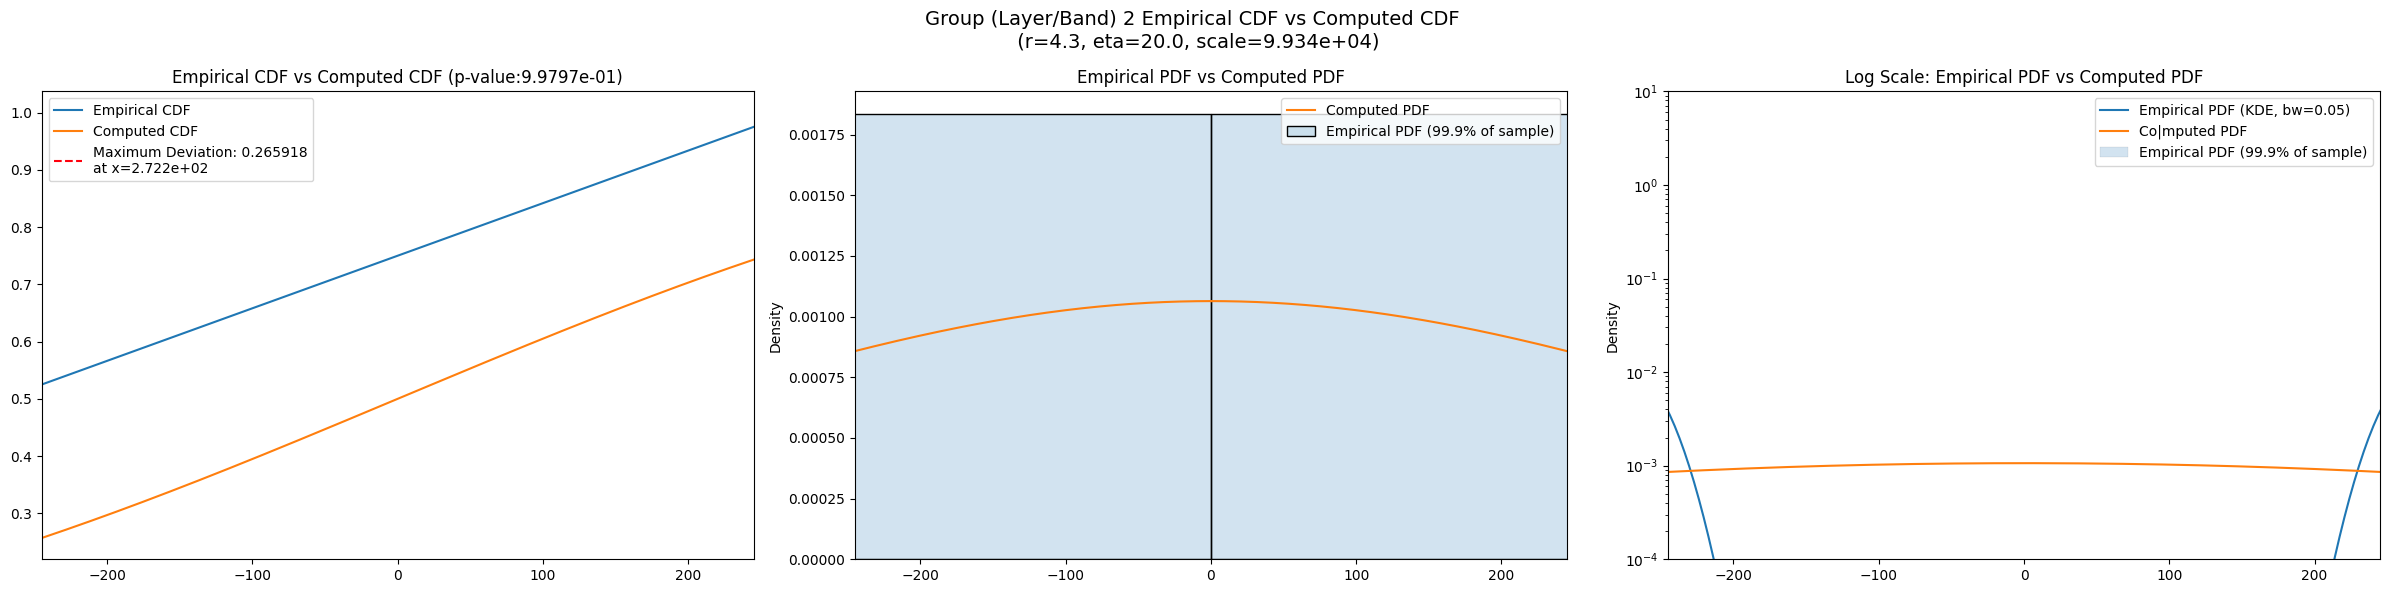

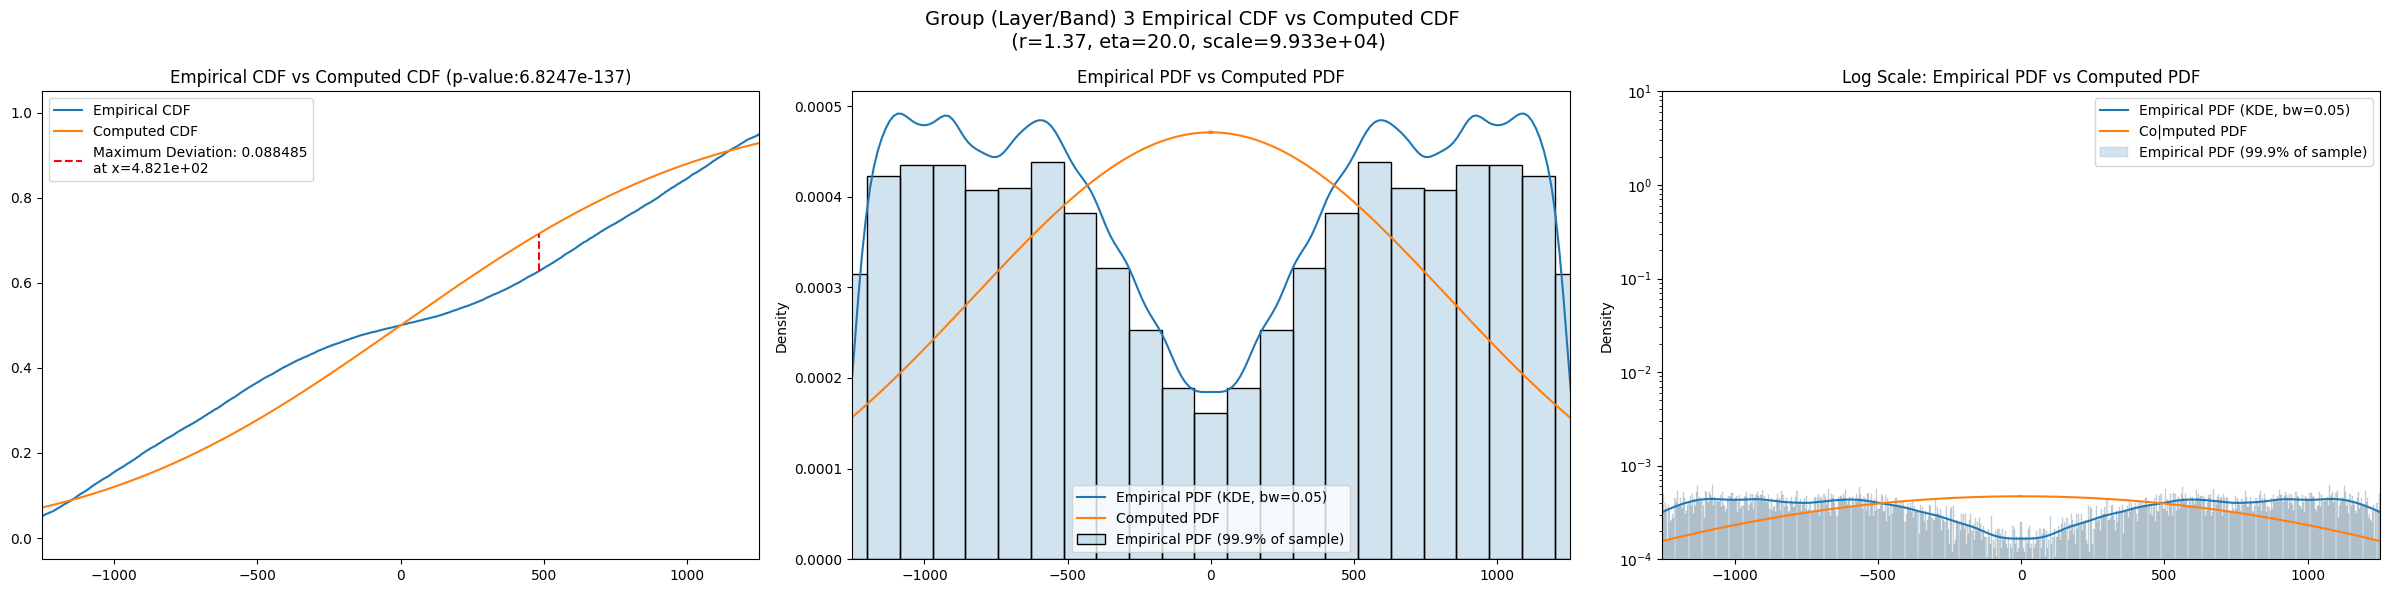

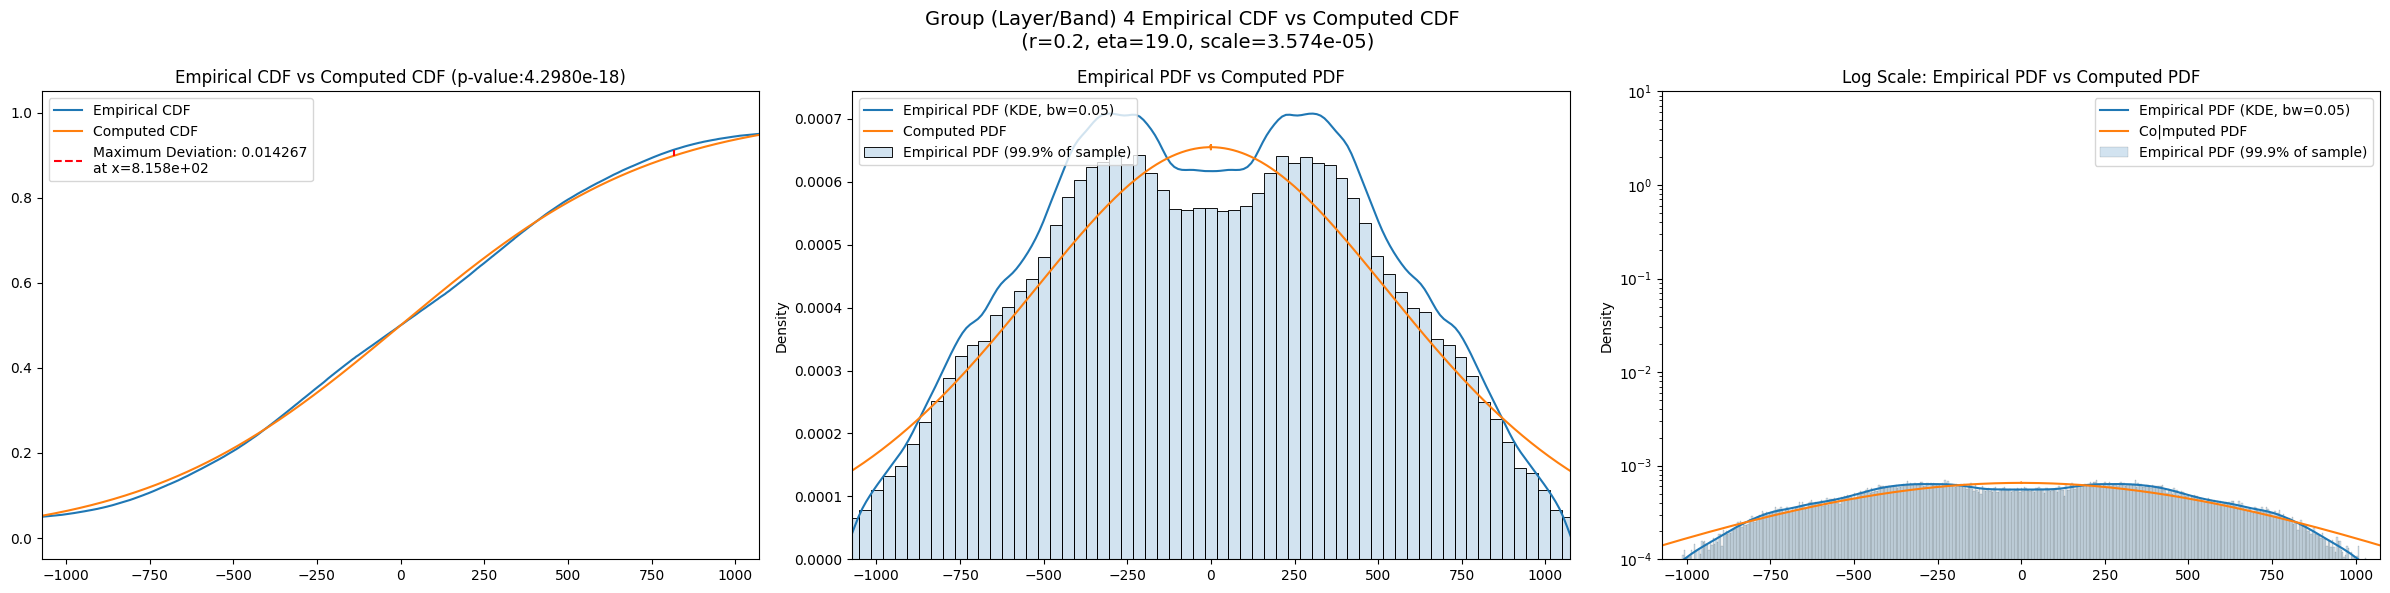

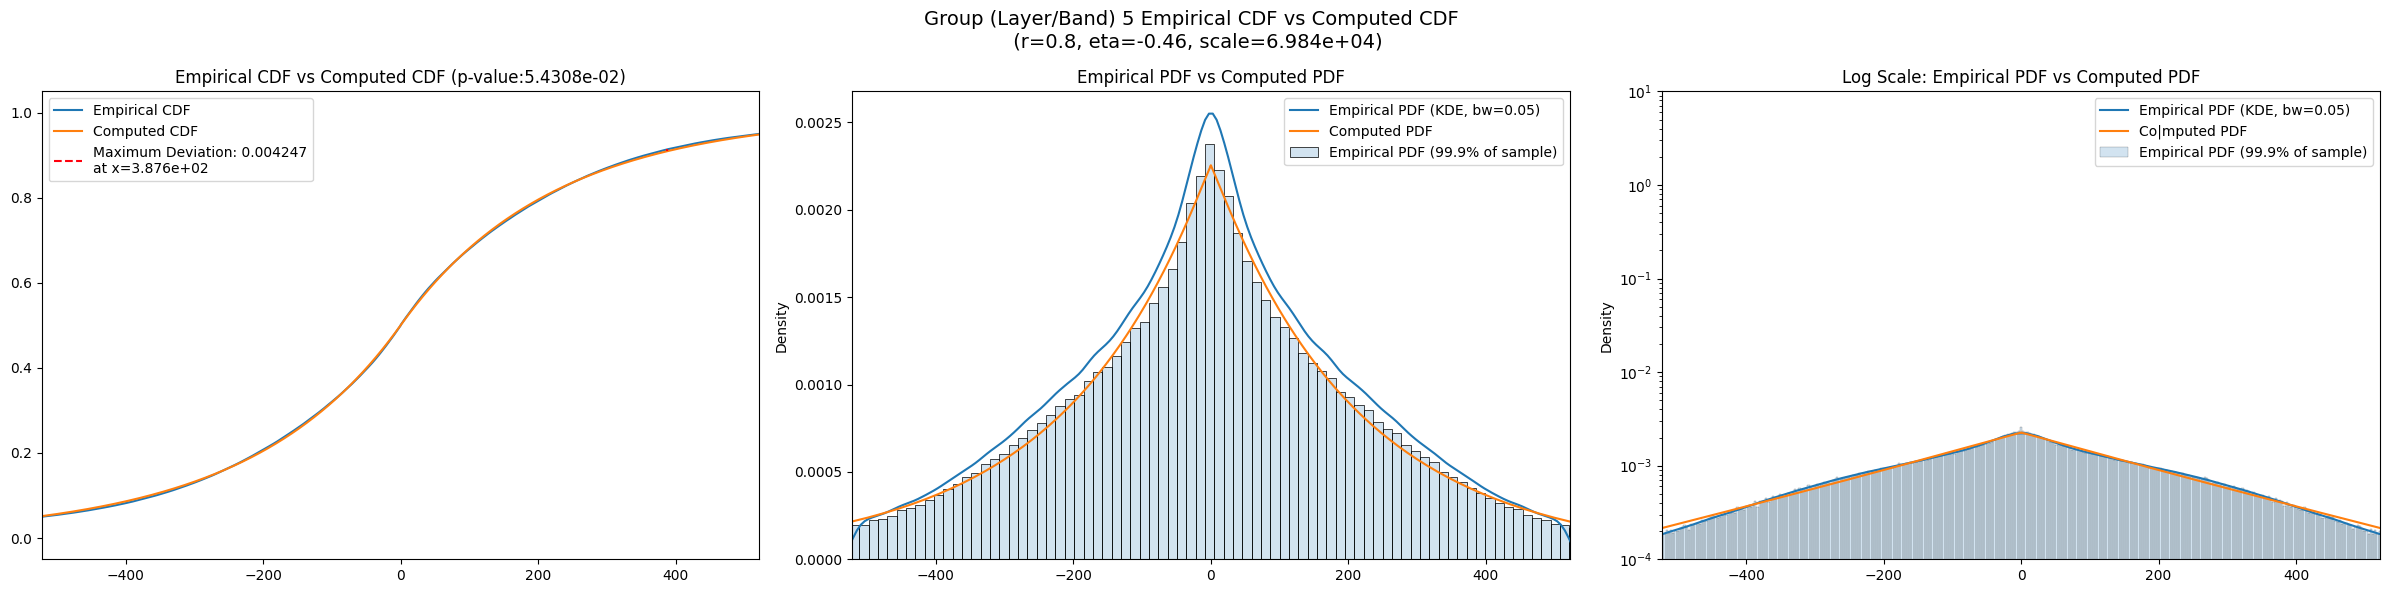

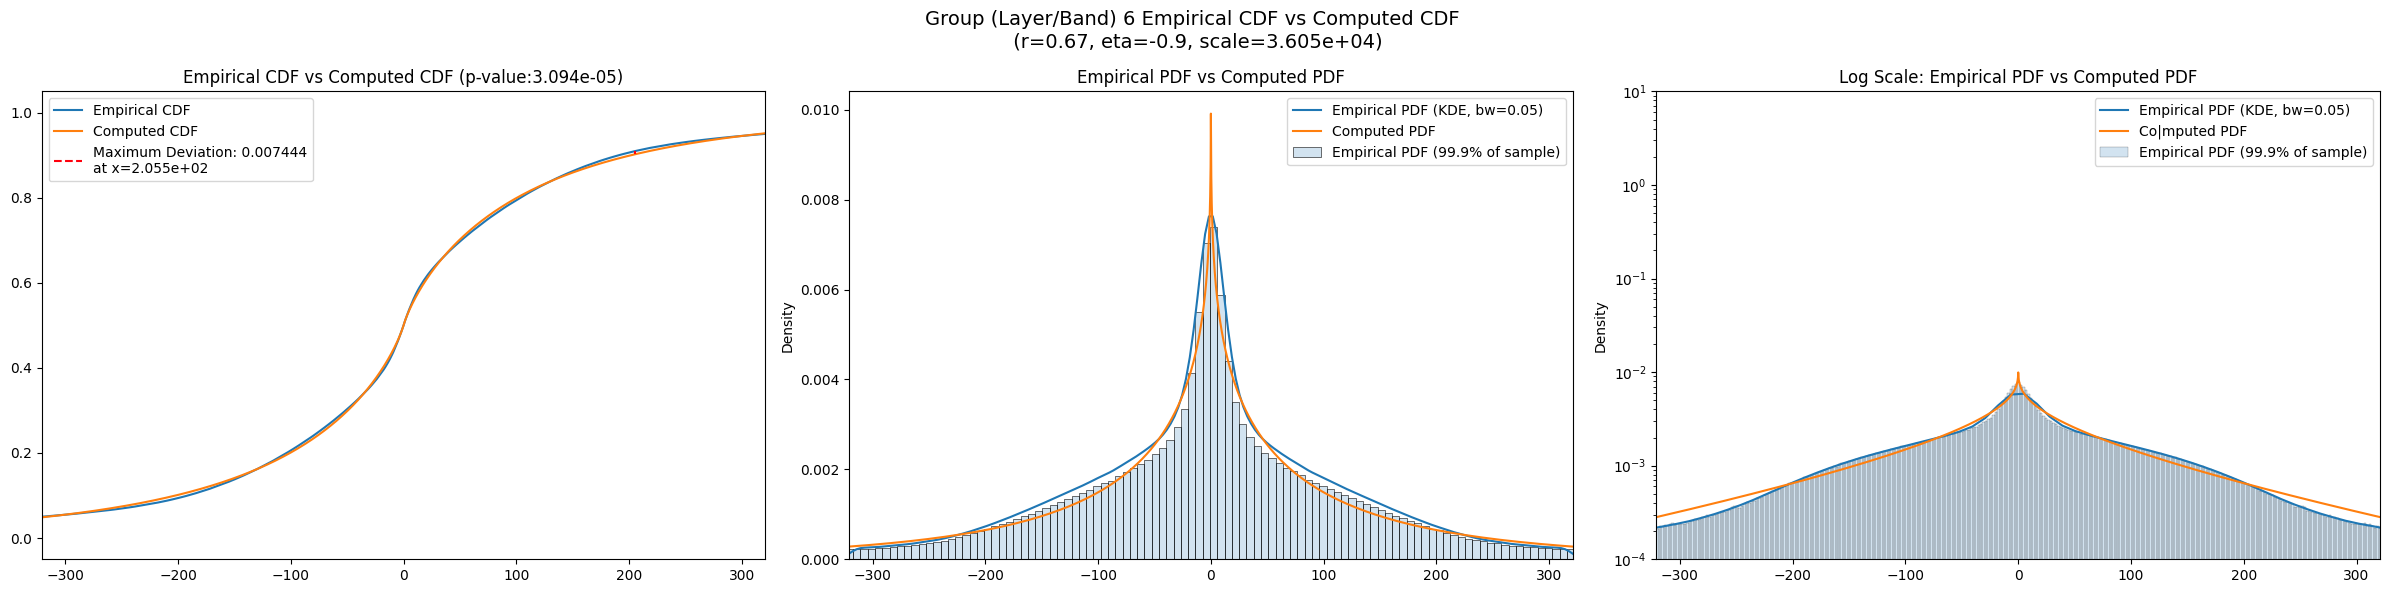

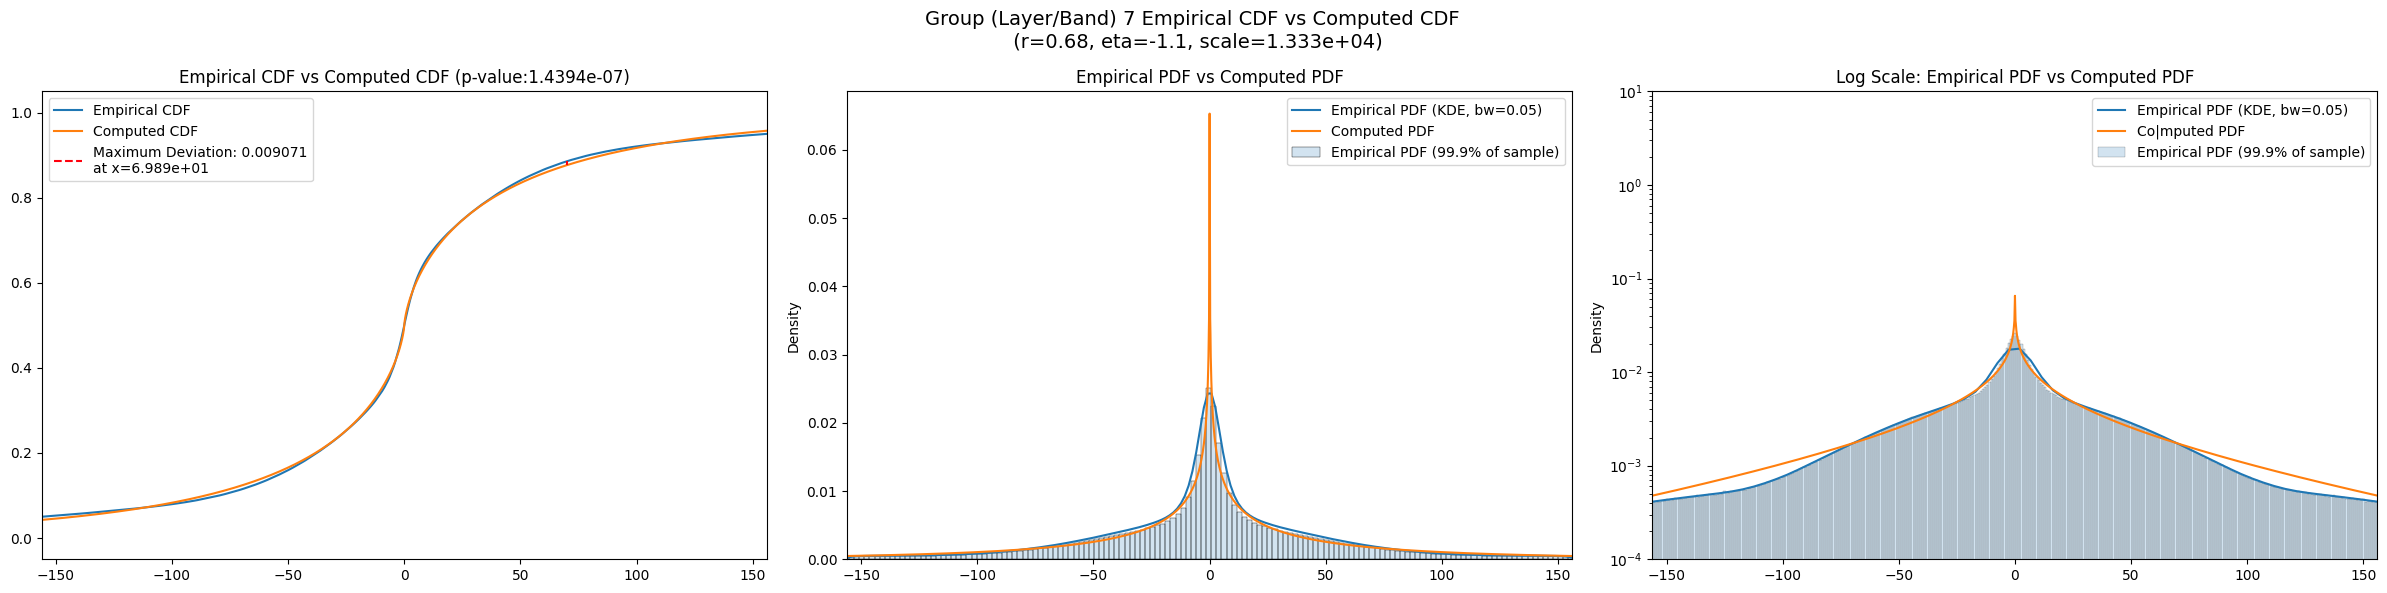

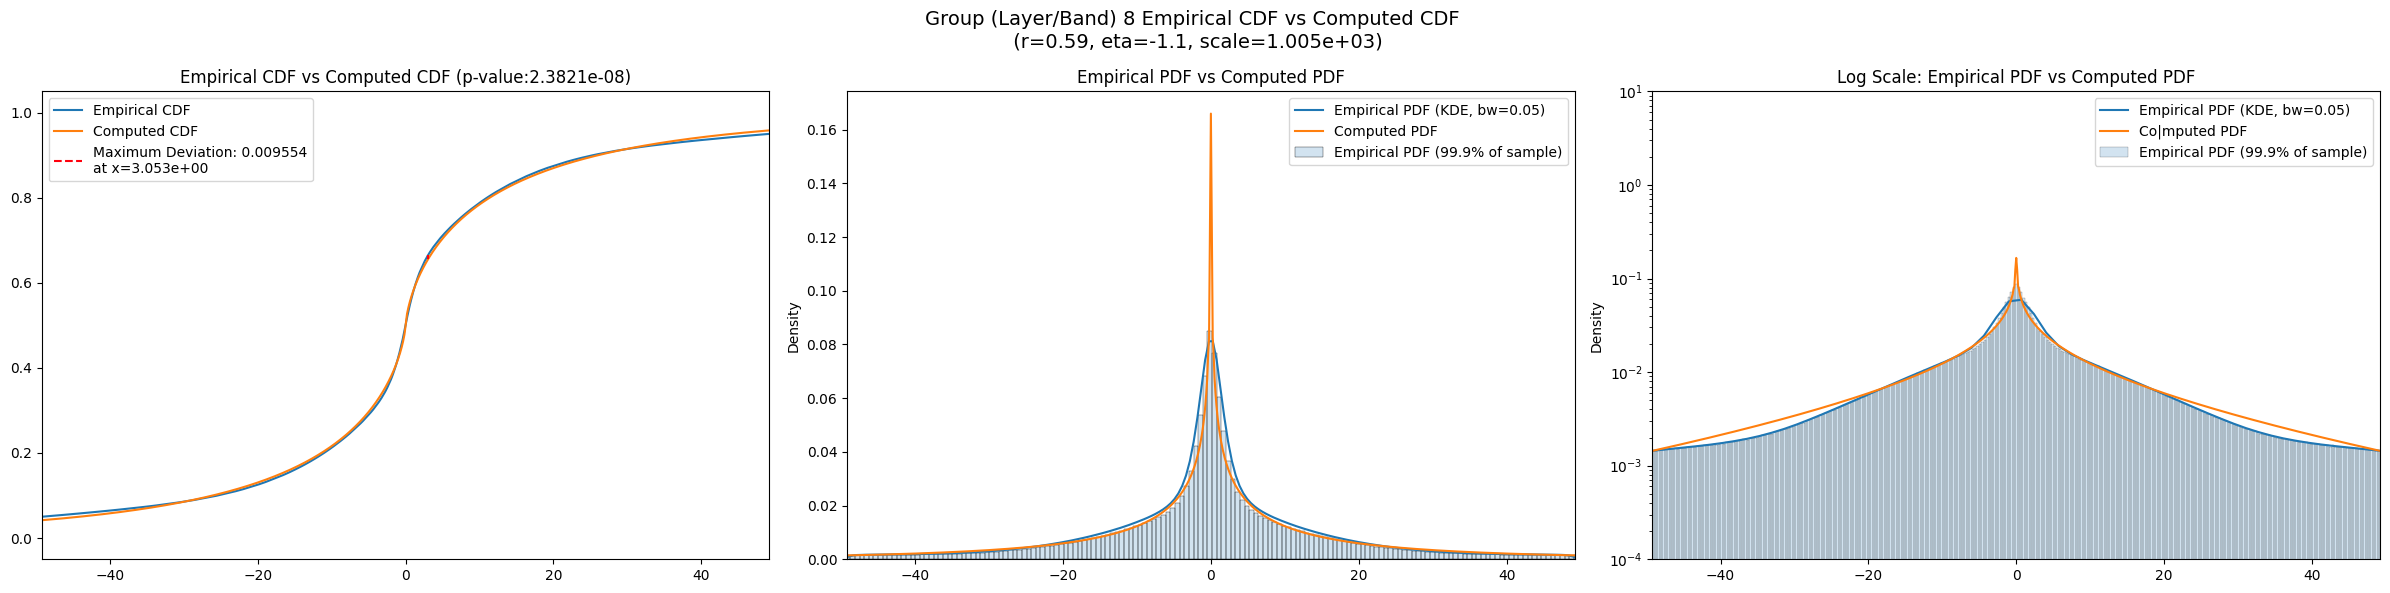

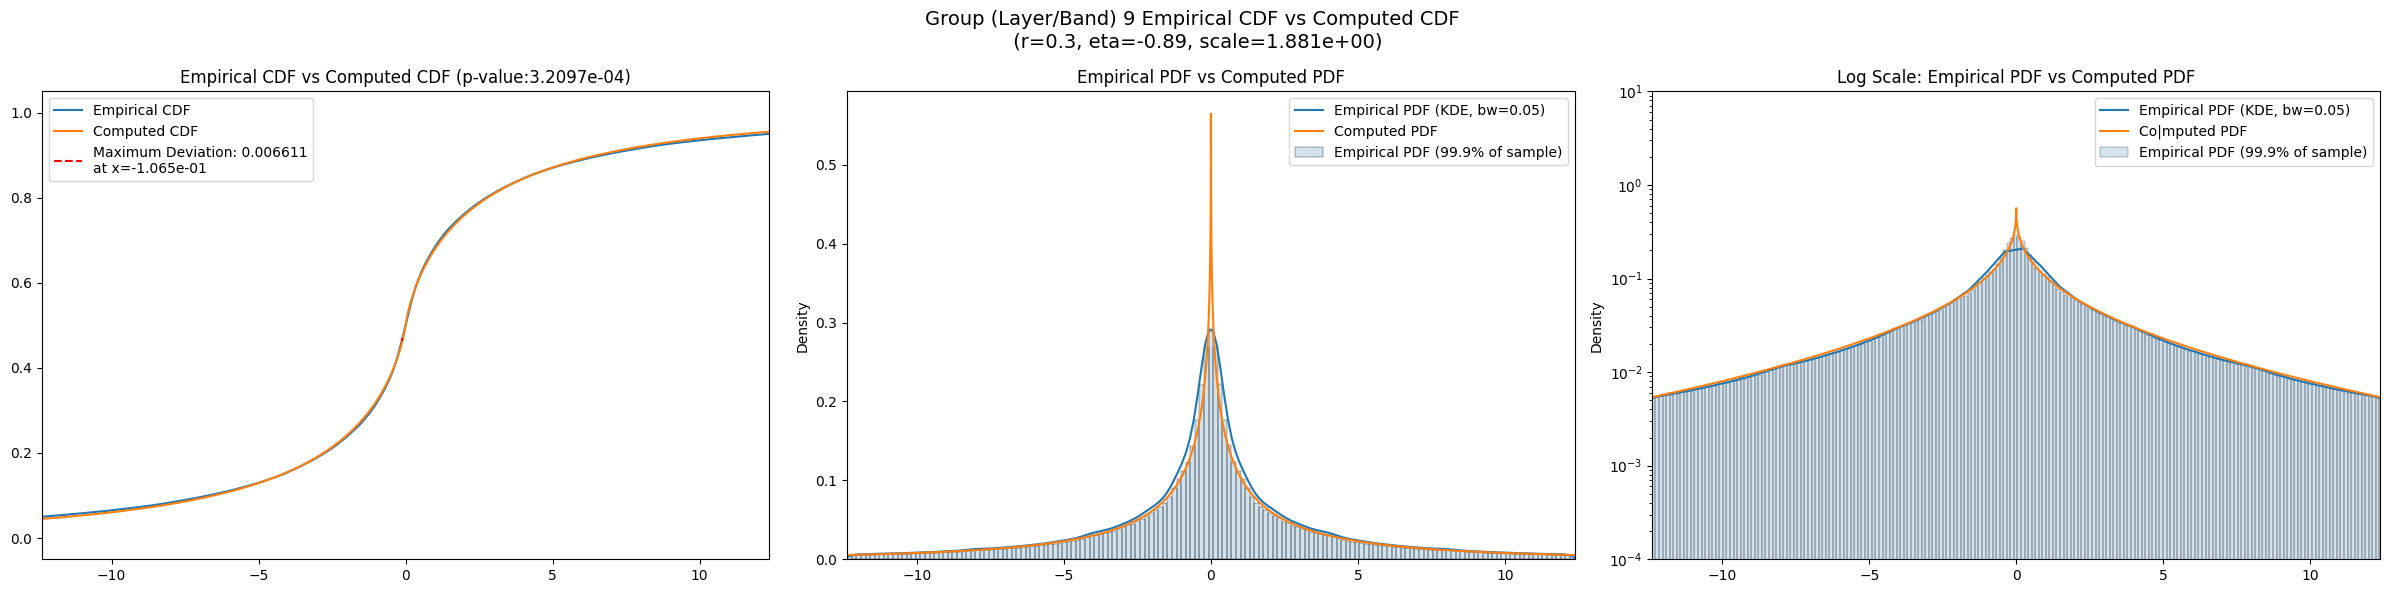

In [16]:
for group in GROUPS:
    group_info = master_df.loc[group]
    best_r = group_info['best_r']
    best_eta = group_info['best_eta']
    best_scale = group_info['best_scale']
    fig = visualize_cdf_pdf(sample = group_data_map[group], 
                    params = (best_r, best_eta, best_scale), 
                    log_scale = True,
                    group = group)
    fig.savefig(os.path.join(CWD, "plots", f'compare_cdf_pdf_layer_{group}.jpg'), bbox_inches = 'tight', dpi = 100)

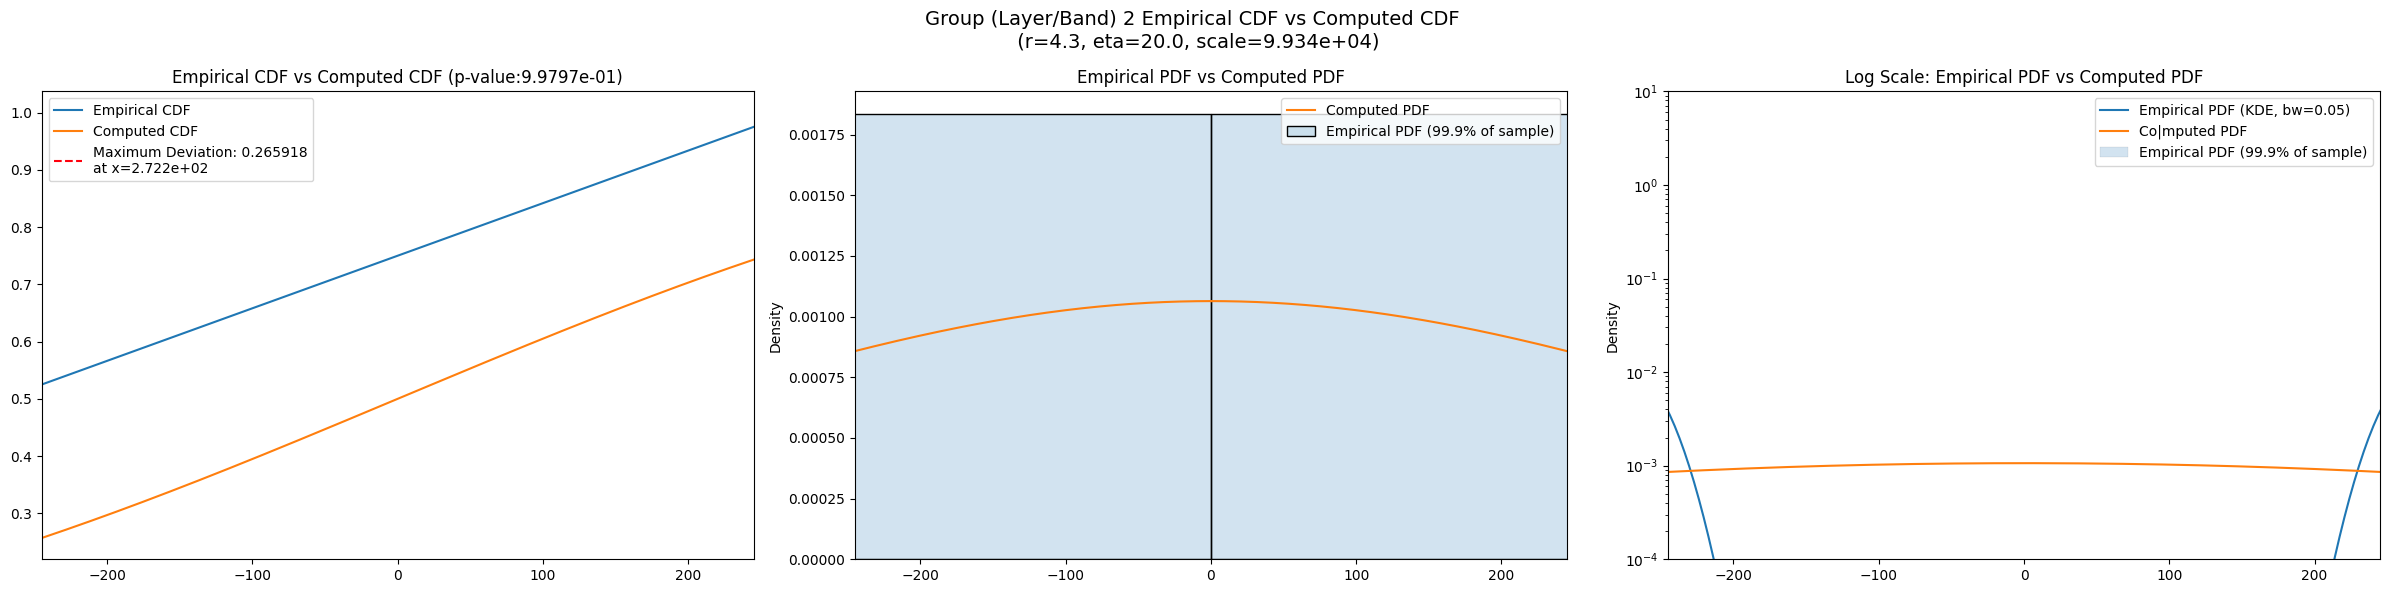

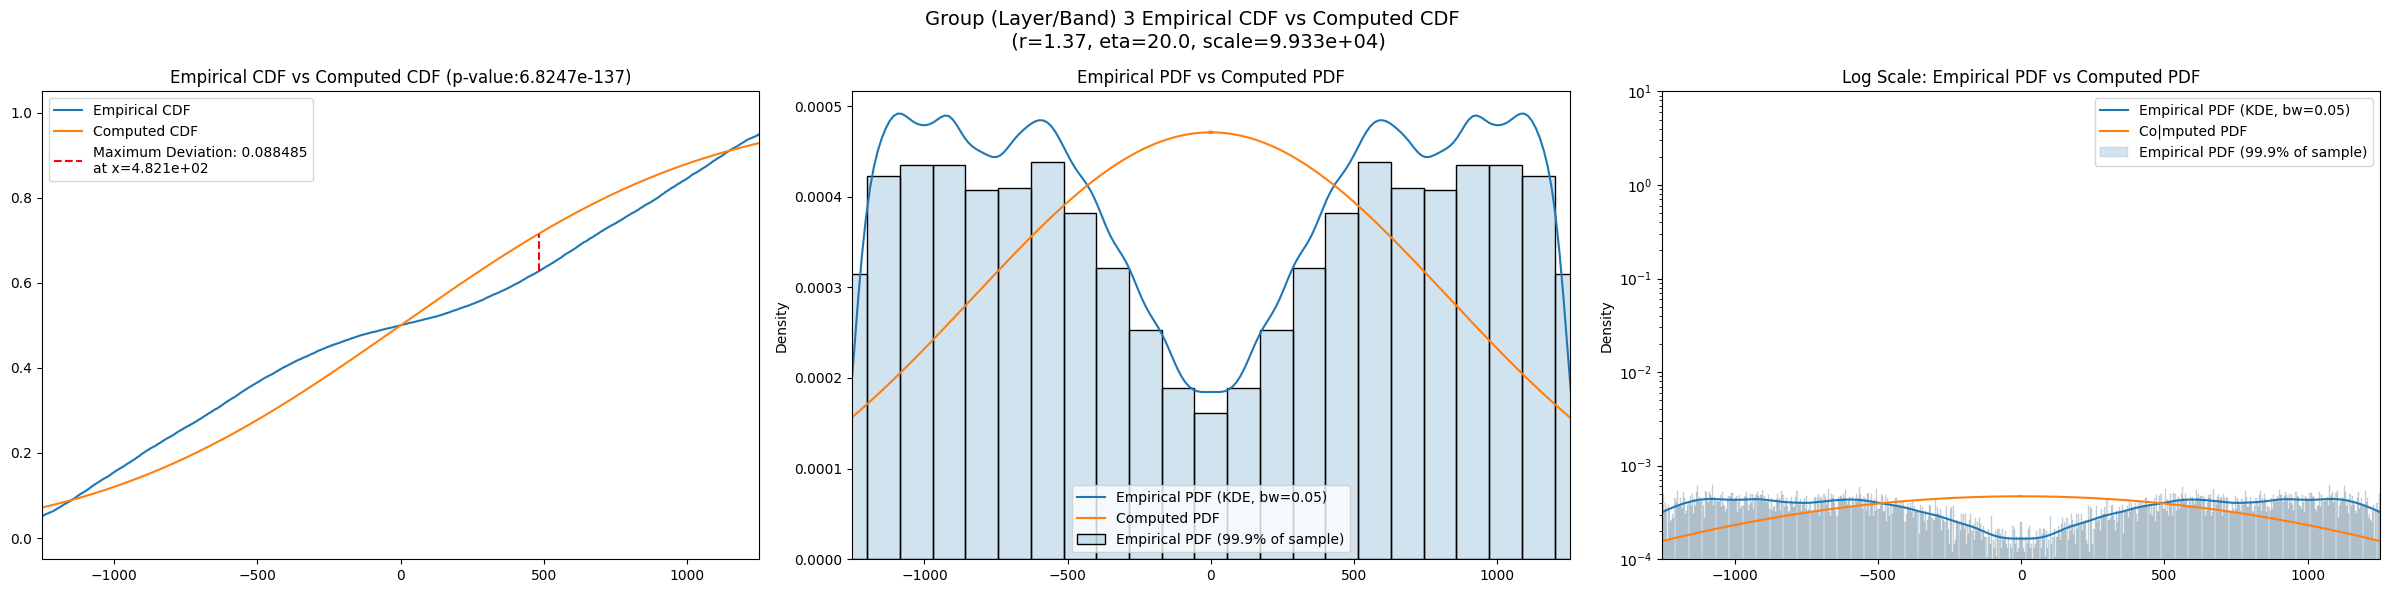

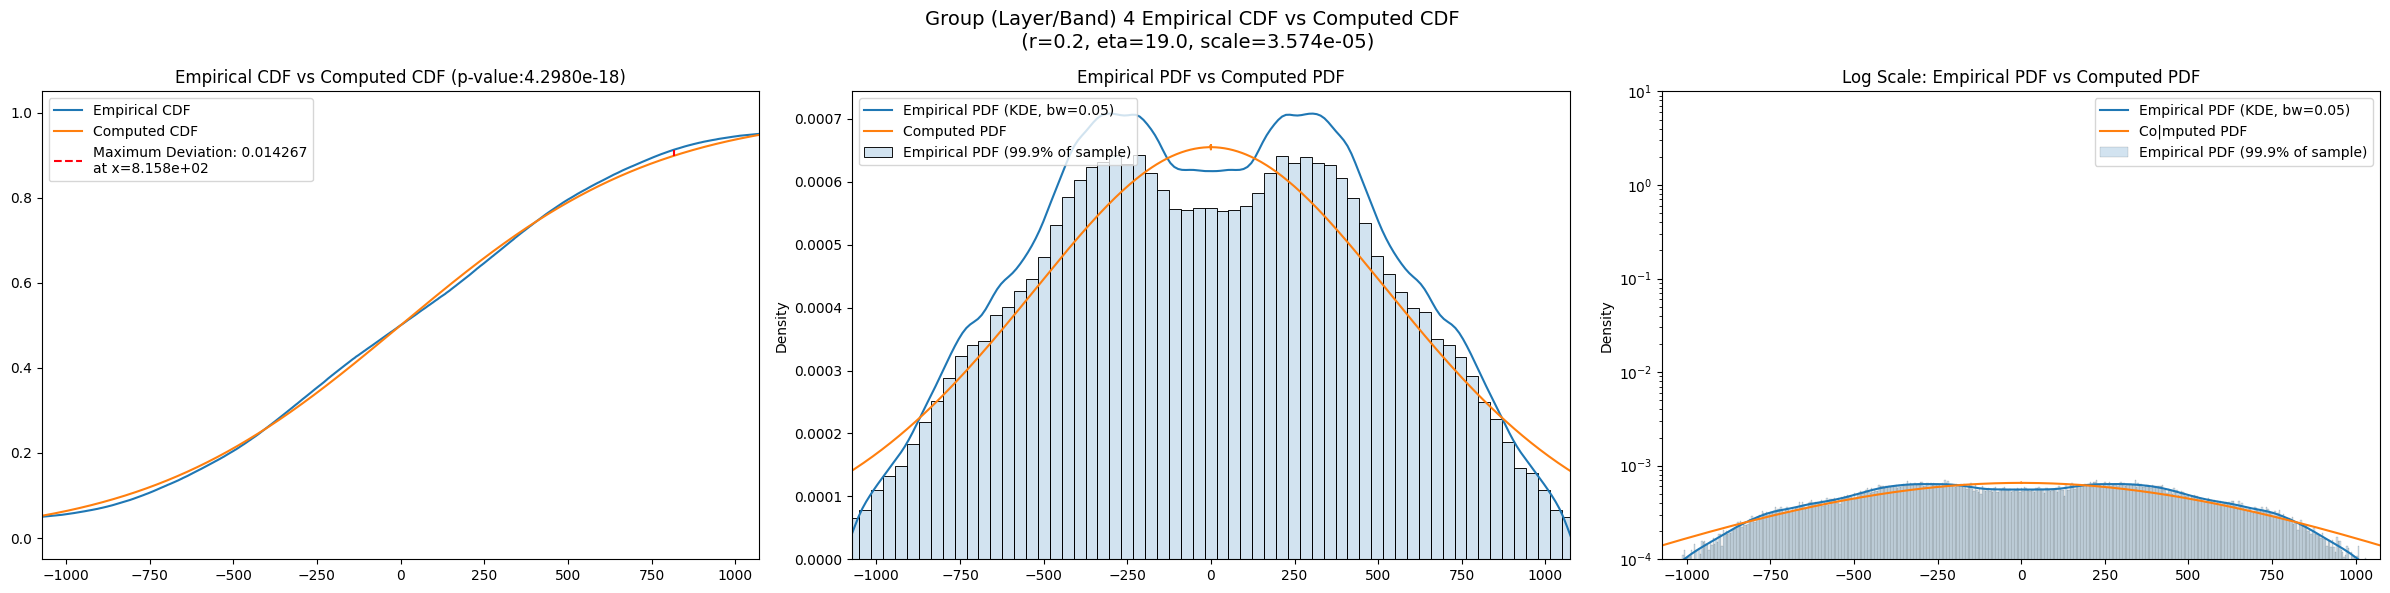

/var/folders/0c/5hhs4r6n7pnc4jcl295d7j_c0000gn/T/ipykernel_3471/3536256052.py:103: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/Users/brandonmarks/opt/anaconda3/envs/HBMV/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


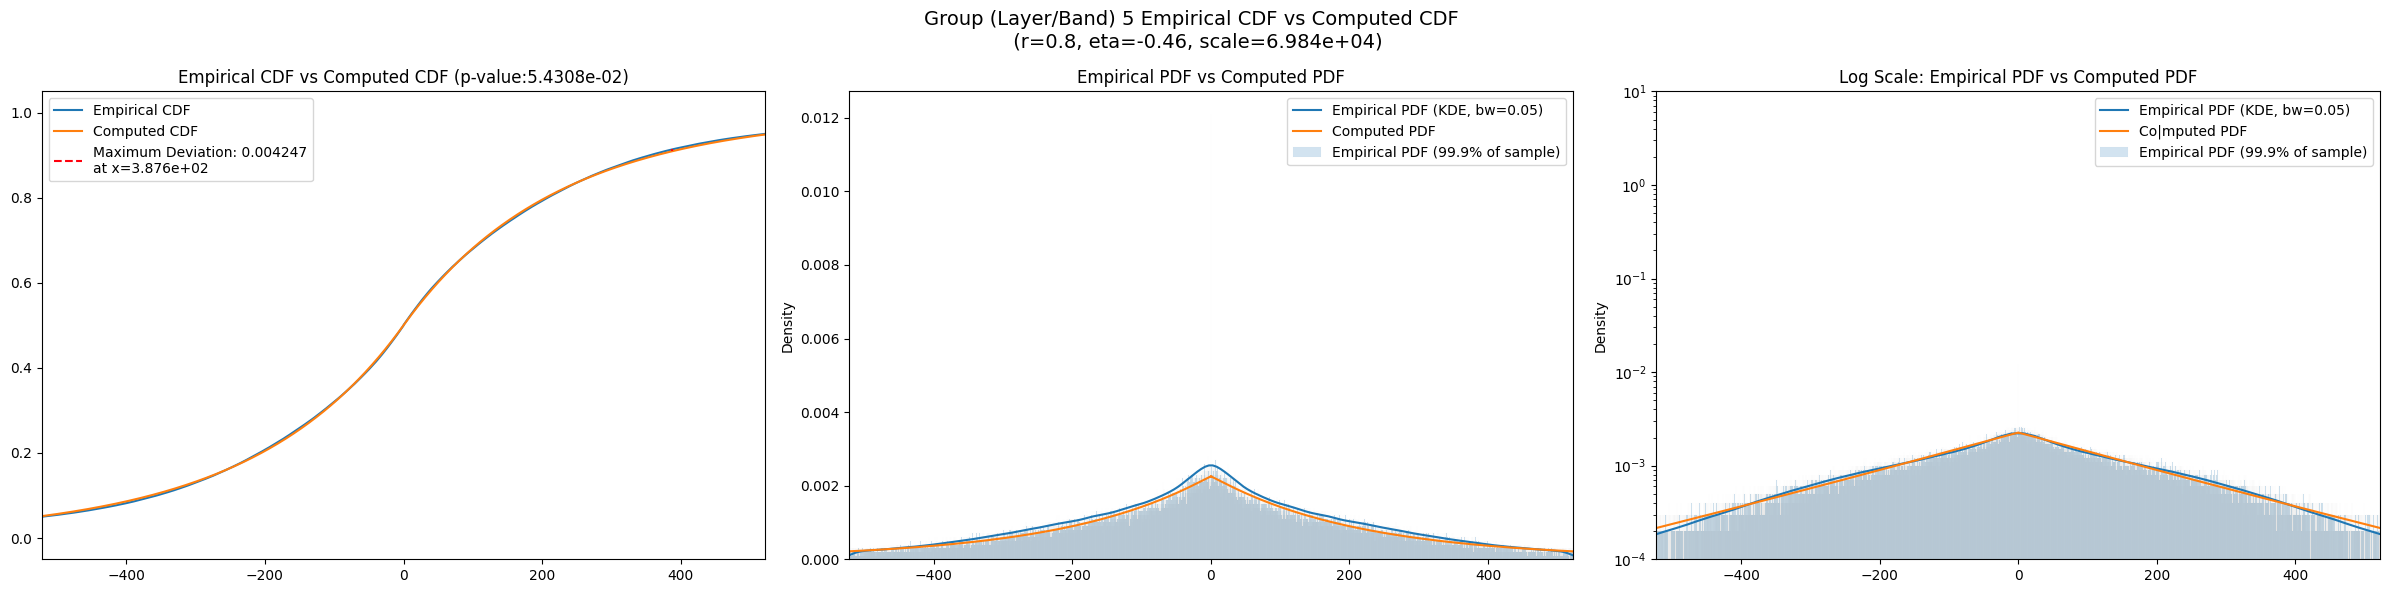

/var/folders/0c/5hhs4r6n7pnc4jcl295d7j_c0000gn/T/ipykernel_3471/3536256052.py:103: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/Users/brandonmarks/opt/anaconda3/envs/HBMV/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


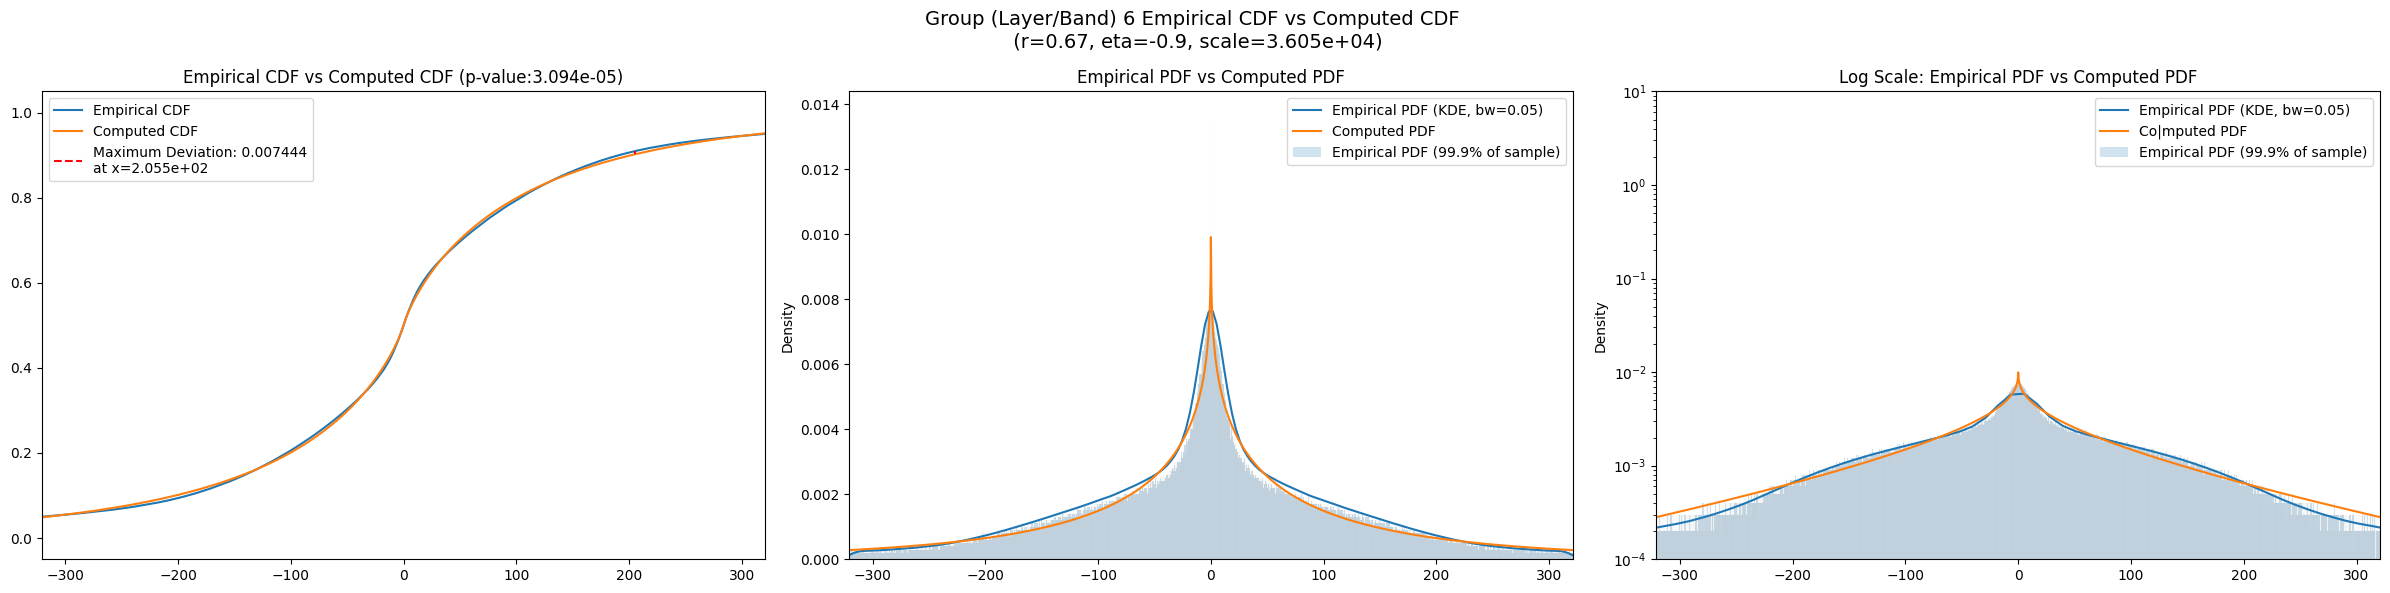

/Users/brandonmarks/opt/anaconda3/envs/HBMV/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


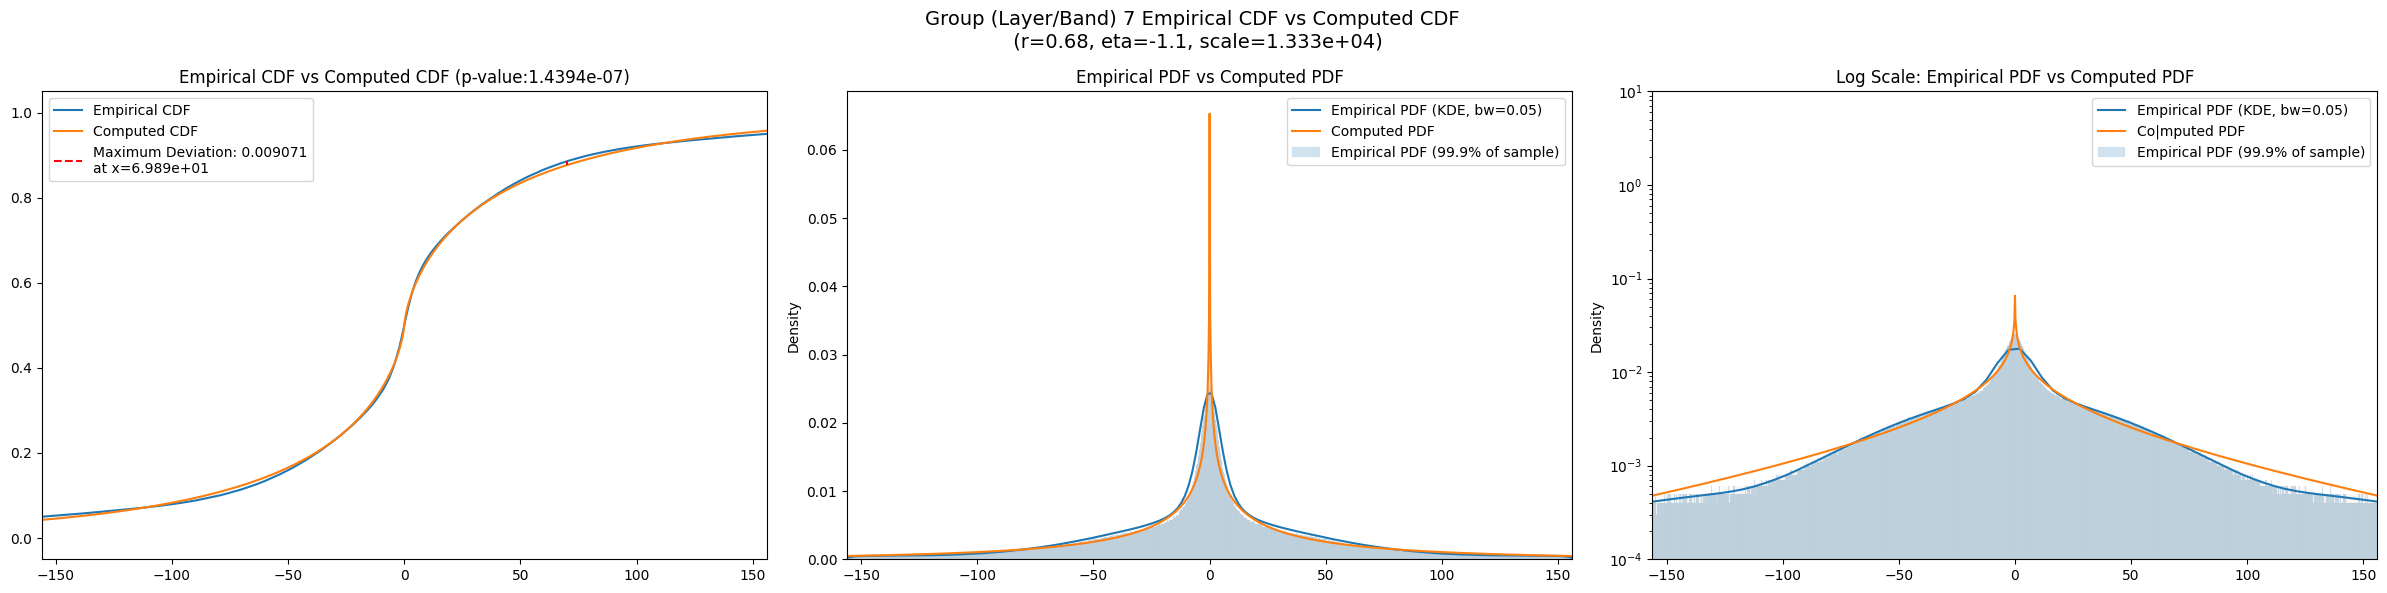

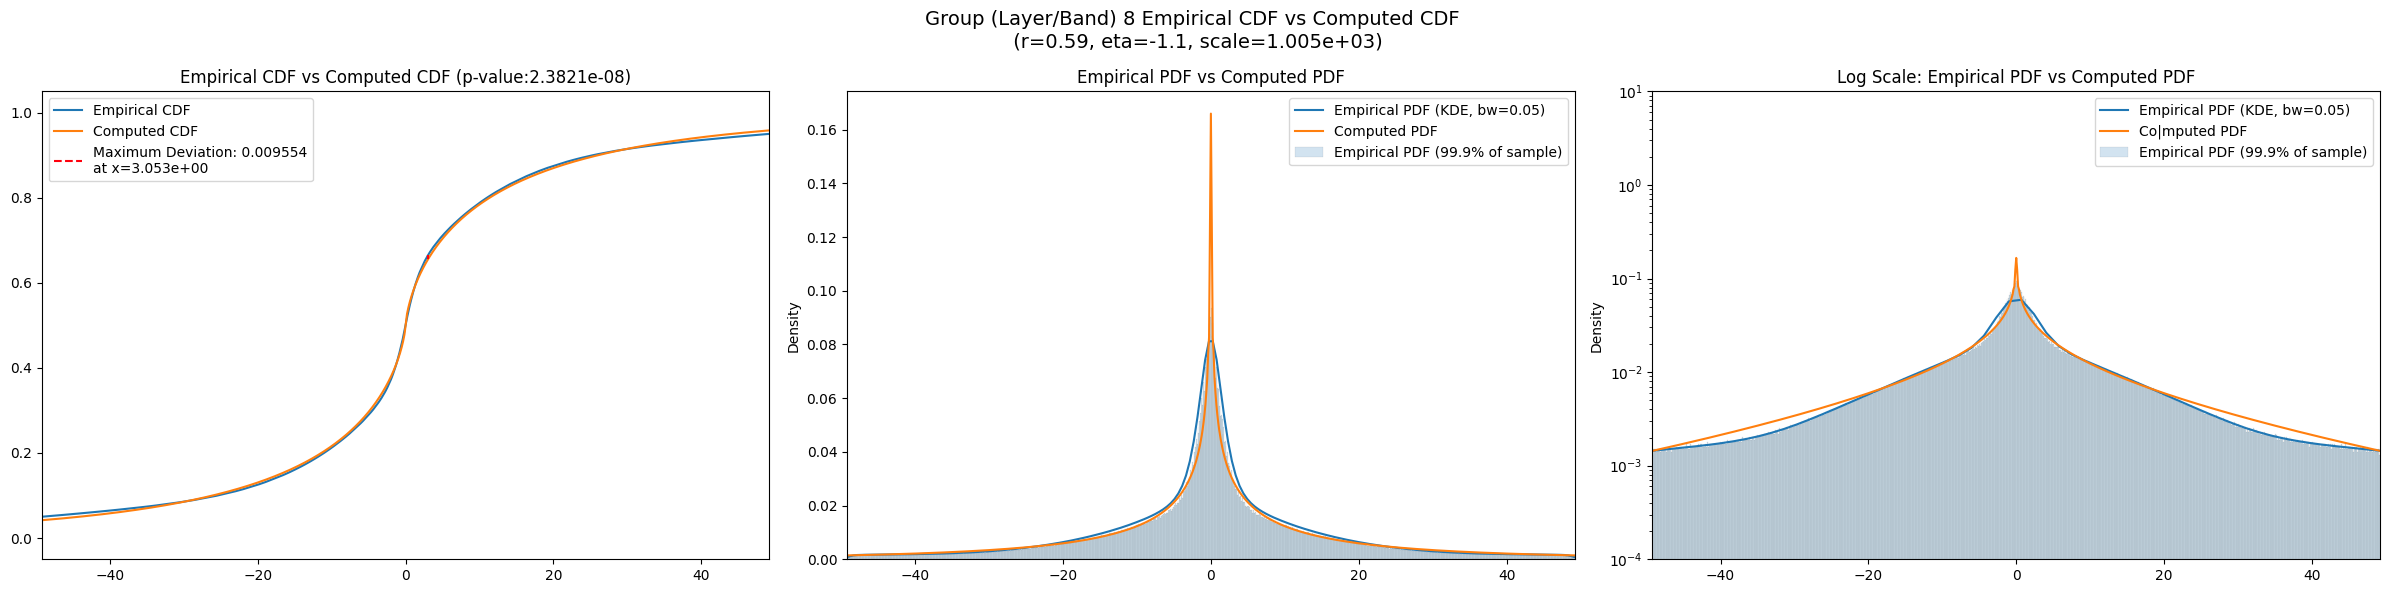

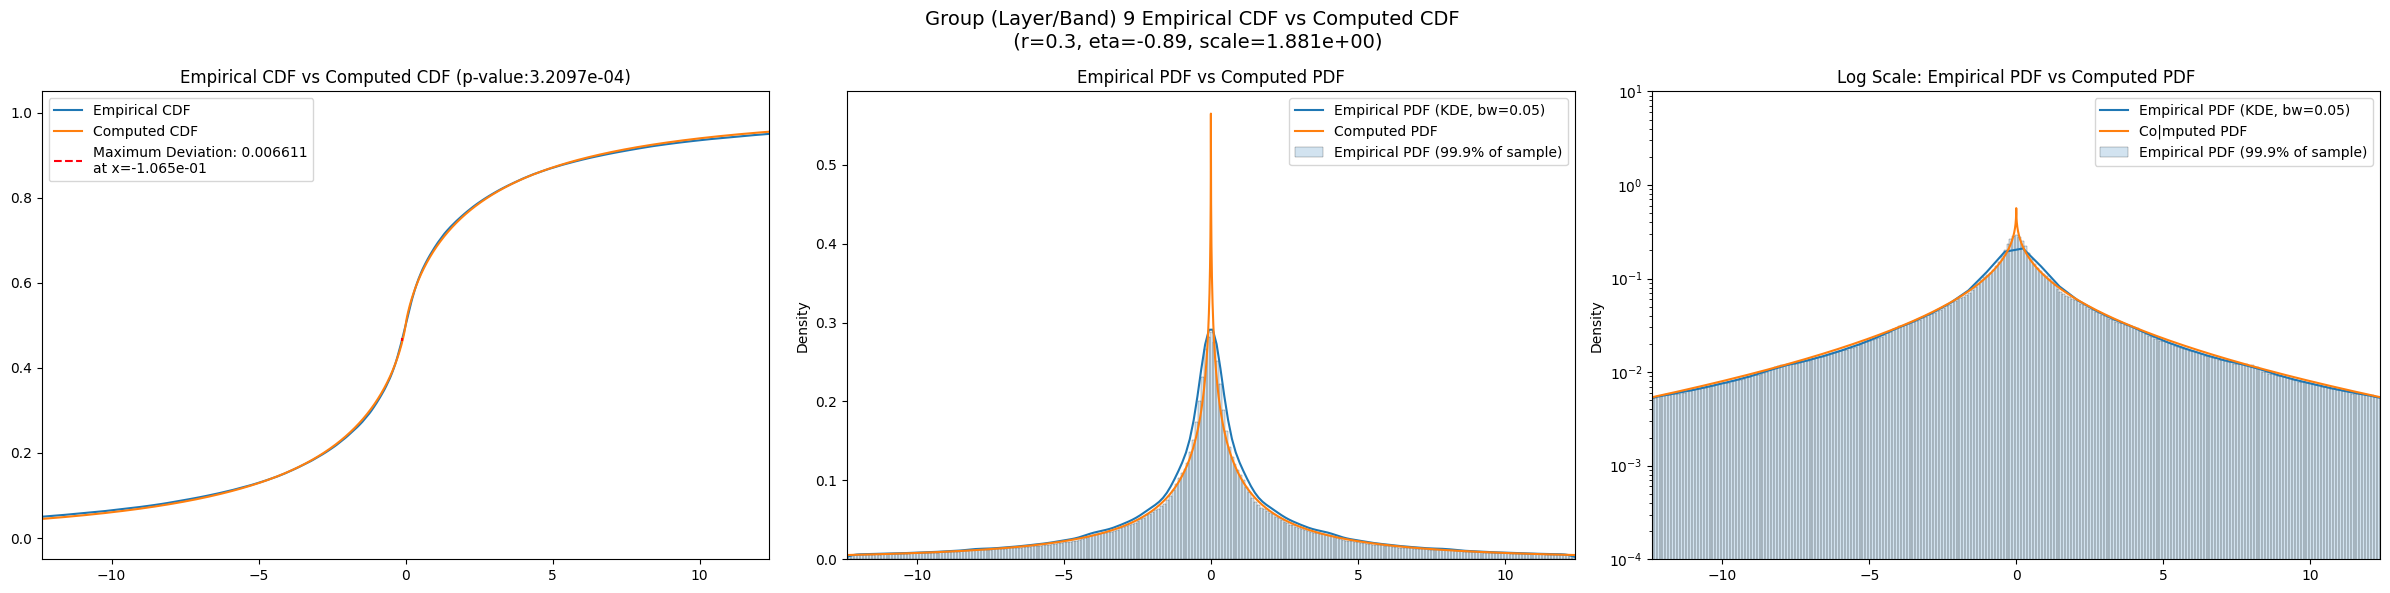

In [17]:
for group in GROUPS:
    group_info = master_df.loc[group]
    best_r = group_info['best_r']
    best_eta = group_info['best_eta']
    best_scale = group_info['best_scale']
    if group > 4:
        binwidth = 0.1
    else:
        binwidth = None
    fig = visualize_cdf_pdf(sample = group_data_map[group], 
                    params = (best_r, best_eta, best_scale), 
                    log_scale = True,
                    group = group, binwidth = binwidth)
    

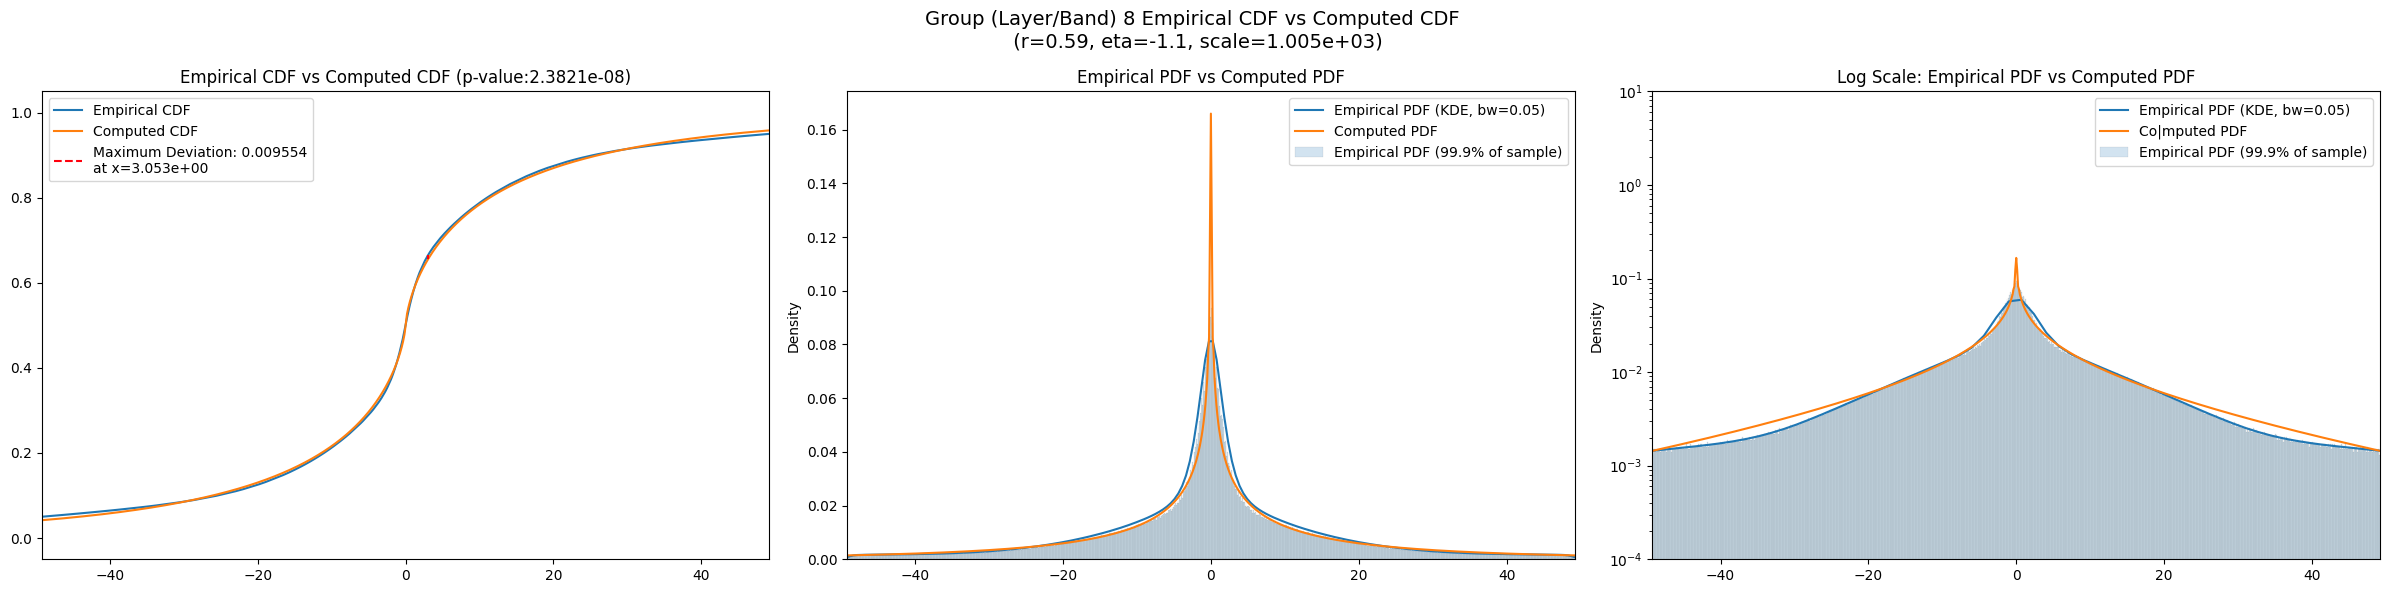

In [18]:
group = 8
group_info = master_df.loc[group]
best_r = group_info['best_r']
best_eta = group_info['best_eta']
best_scale = group_info['best_scale']
fig = visualize_cdf_pdf(sample = group_data_map[group], 
                params = (best_r, best_eta, best_scale), 
                log_scale = True,
                group = group, binwidth=0.1)

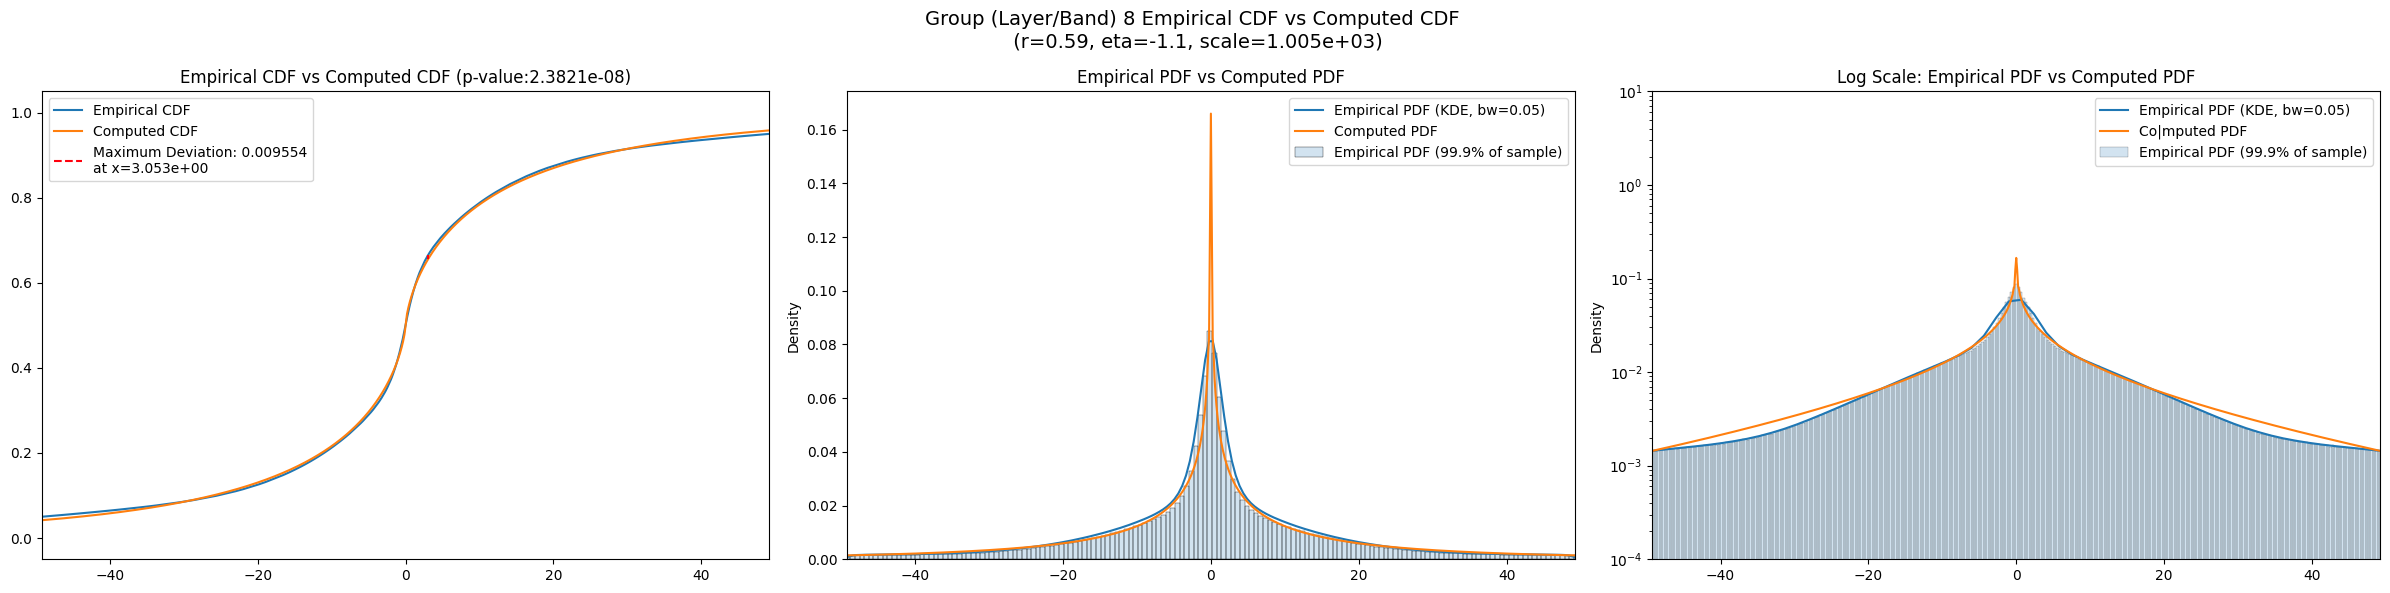

In [19]:
group = 8
group_info = master_df.loc[group]
best_r = group_info['best_r']
best_eta = group_info['best_eta']
best_scale = group_info['best_scale']
fig = visualize_cdf_pdf(sample = group_data_map[group], 
                params = (best_r, best_eta, best_scale), 
                log_scale = True,
                group = group, binwidth=None)

## Comparing with Gaussian and Laplace Priors

In [20]:
def generate_func(sample, distro, *args, n_samples=200):
    if distro == 'gaussian' or distro == 'normal':
        def var_func(var):
            cdf = scipy.stats.norm(scale=var).cdf
            return compute_ksstat(sample, cdf)
        return var_func
    elif distro == 'laplace':
        def var_func(var):
            cdf = scipy.stats.laplace(scale=var).cdf
            return compute_ksstat(sample, cdf)
        return var_func
    elif distro == 't':
        def var_func(var):
            cdf = scipy.stats.t(df=2, scale=var).cdf
            return compute_ksstat(sample, cdf)
        return var_func
    elif distro == 'prior_r':
        eta = args[0]
        def r_func(r):
            cdf = compute_prior_cdf(r, eta, n_samples=n_samples)
            return compute_ksstat(sample, cdf)
        return r_func
    elif distro == 'prior_eta':
        r = args[0]
        def eta_func(eta):
            cdf = compute_prior_cdf(r, eta, n_samples=n_samples)
            return compute_ksstat(sample, cdf)
        return eta_func
    elif distro == 'prior':
        def r_eta_func(params):
            r = params[0]
            eta = params[1]
            cdf = compute_prior_cdf(r, eta, n_samples=n_samples, debug=False)
            return compute_ksstat(sample, cdf)
        return r_eta_func
    elif distro == 'prior_with_scale':
        def r_eta_scale_func(params):
            r = params[0]
            eta = params[1]
            scale = params[2]
            print(r, eta, scale)
            cdf = compute_prior_cdf(r = r, eta = eta, n_samples=n_samples, debug=False)
            return compute_ksstat(sample/ np.sqrt(scale), cdf)
        return r_eta_scale_func

    print("Please enter a valid argument for `distro`: 'gaussian', 'laplace', 'prior_r', 'prior_eta', 'prior','prior_with_scale', 't'")

In [21]:
master_df_path = Path(os.path.join(CWD, "CSVs", 'master_df.csv'))

if RERUN or not master_df_path.exists():
    upper_bound = int(1e6)
    for group in GROUPS:
        norm_result = scipy.optimize.minimize_scalar(generate_func(group_data_map[group], 'gaussian'), method = 'bounded', bounds = (0, upper_bound))
        laplace_result = scipy.optimize.minimize_scalar(generate_func(group_data_map[group], 'laplace'), method = 'bounded', bounds = (0, upper_bound))
        t_result = scipy.optimize.minimize_scalar(generate_func(group_data_map[group], 't'), method = 'bounded', bounds = (0, upper_bound))
        
        master_df.loc[group, 'param_gaussian'] = round_to_sigfigs(norm_result['x'], 6)
        master_df.loc[group, 'kstest_stat_gaussian'] = round_to_sigfigs(norm_result['fun'], 6)
        master_df.loc[group, 'kstest_pval_gaussian'] = round_to_sigfigs(stats.kstwo(n=master_df.loc[group, 'total_samples']).sf(master_df.loc[group, 'kstest_stat_gaussian']), 6)

        master_df.loc[group, 'param_laplace'] = round_to_sigfigs(laplace_result['x'], 6)
        master_df.loc[group, 'kstest_stat_laplace'] = round_to_sigfigs(laplace_result['fun'], 6)
        master_df.loc[group, 'kstest_pval_laplace'] = round_to_sigfigs(stats.kstwo(n=master_df.loc[group, 'total_samples']).sf(master_df.loc[group, 'kstest_stat_laplace']), 6)

        master_df.loc[group, 'param_laplace'] = round_to_sigfigs(laplace_result['x'], 6)
        master_df.loc[group, 'kstest_stat_laplace'] = round_to_sigfigs(laplace_result['fun'], 6)
        master_df.loc[group, 'kstest_pval_laplace'] = round_to_sigfigs(stats.kstwo(n=master_df.loc[group, 'total_samples']).sf(master_df.loc[group, 'kstest_stat_laplace']), 6) 

        master_df.loc[group, 'param_t'] = round_to_sigfigs(t_result['x'], 6)
        master_df.loc[group, 'kstest_stat_t'] = round_to_sigfigs(t_result['fun'], 6)
        master_df.loc[group, 'kstest_pval_t'] = round_to_sigfigs(stats.kstwo(n=master_df.loc[group, 'total_samples']).sf(master_df.loc[group, 'kstest_stat_t']), 6) 

        master_df.loc[group, 'kstest_pval_gengamma'] = round_to_sigfigs(stats.kstwo(n=master_df.loc[group, 'total_samples']).sf(master_df.loc[group, 'kstest_stat_best']))

    master_df.to_csv(os.path.join(CWD, "CSVs", 'master_df.csv'))
    
master_df = pd.read_csv(os.path.join(CWD, "CSVs", 'master_df.csv'), index_col = GROUP)
master_df

,obs_var,var_lower,var_upper,obs_kurt,kurt_lower,kurt_upper,total_samples,kstest_stat_initial,initial_r,initial_eta,...,param_gaussian,kstest_stat_gaussian,kstest_pval_gaussian,param_laplace,kstest_stat_laplace,kstest_pval_laplace,param_t,kstest_stat_t,kstest_pval_t,kstest_pval_gengamma
layer,,,,,,,,,,,,,,,,,,,,,
2,141841.72000,0.000000,209572.11000,-1.771987,NaN,NaN,4.0,0.265918,4.3,20.0,...,533.05200,0.195222,9.906630e-01,514.60000,0.205409,9.839470e-01,436.00400,0.201946,9.865390e-01,8.678729e-01
3,736460.30000,720182.060000,752624.20000,-1.273356,-1.336073,-1.193367,20050.0,0.088740,1.3,20.0,...,987.74400,0.061776,5.836750e-67,884.19400,0.086364,1.468700e-130,738.03700,0.083629,1.944790e-122,1.795330e-137
4,465219.00000,445174.600000,485257.53000,0.832306,0.714066,0.962902,180942.0,0.013893,0.2,19.0,...,653.30300,0.018661,3.645030e-55,570.81600,0.033409,6.736920e-176,473.59300,0.029025,7.311000e-133,9.168615e-31
5,108838.26600,102539.490000,115350.62500,3.238030,2.715251,3.809224,922650.0,0.004231,0.9,-0.5,...,257.47400,0.029410,0.000000e+00,227.40000,0.005047,7.691640e-21,186.00500,0.010529,2.833590e-89,3.581416e-12
6,47219.99000,43794.440000,50741.45700,6.126480,5.564133,6.721452,4185552.0,0.008056,0.7,-0.9,...,122.59300,0.049473,0.000000e+00,105.12400,0.026863,0.000000e+00,84.22810,0.030873,0.000000e+00,1.287917e-198
7,9147.18800,8511.764000,9801.52700,5.519940,5.009598,6.143659,17688454.0,0.009162,0.7,-1.1,...,43.95150,0.068660,0.000000e+00,38.24210,0.045826,0.000000e+00,29.28370,0.046043,0.000000e+00,0.000000e+00
8,918.93930,848.773740,993.63250,7.176670,5.902757,11.482376,72685058.0,0.009454,0.6,-1.1,...,13.28390,0.074117,0.000000e+00,11.54900,0.050151,0.000000e+00,8.83745,0.049777,0.000000e+00,0.000000e+00
9,78.41065,70.487915,87.48717,15.212063,10.426363,33.707012,295085108.0,0.007687,0.3,-0.9,...,3.54259,0.072795,0.000000e+00,3.07733,0.046889,0.000000e+00,2.38568,0.047191,0.000000e+00,0.000000e+00


## Results

In [22]:
import pandas as pd
import os
master_df = pd.read_csv(os.path.join(os.getcwd(), "CSVs", 'master_df.csv'), index_col = 0)

In [23]:
master_df.filter(regex="kstest_stat.*")

,kstest_stat_initial,kstest_stat_cutoff_0.05,kstest_stat_best,kstest_stat_gaussian,kstest_stat_laplace,kstest_stat_t
layer,,,,,,
2,0.265918,0.623939,0.265918,0.195222,0.205409,0.201946
3,0.088740,0.009583,0.088624,0.061776,0.086364,0.083629
4,0.013893,0.003192,0.013893,0.018661,0.033409,0.029025
5,0.004231,0.001414,0.003828,0.029410,0.005047,0.010529
6,0.008056,0.000664,0.007383,0.049473,0.026863,0.030873
7,0.009162,0.000323,0.008740,0.068660,0.045826,0.046043
8,0.009454,0.000159,0.009383,0.074117,0.050151,0.049777
9,0.007687,0.000079,0.006637,0.072795,0.046889,0.047191


In [24]:
master_df.filter(regex="best.*")

,best_augmented_var,kstest_stat_best,best_r,best_eta,best_scale,best_exclude_cutoff
layer,,,,,,
2,141841.720000,0.265918,4.30,20.00,99341.823024,0.0
3,736460.312500,0.088624,1.37,20.00,99329.120756,0.0
4,445176.750000,0.013893,0.20,19.00,0.000036,250.0
5,107210.132812,0.003828,0.80,-0.46,69837.224568,25.0
6,41444.265625,0.007383,0.67,-0.90,36054.261710,275.0
7,9018.613281,0.008740,0.68,-1.10,13328.861945,25.0
8,918.939270,0.009383,0.59,-1.10,1004.580200,0.0
9,78.410652,0.006637,0.30,-0.89,1.880653,0.0


In [25]:
#eng.quit()